In [1]:
import torch
import torchvision
import torchvision.transforms as transforms


import numpy as np

import torch.optim as optim
from sympy.codegen.ast import none
from torch.utils.data import dataloader

from torch.utils.data import random_split, DataLoader

import threading

from agents.Classe_agent import Agent
from metrics import metrics_plot
from topologies.NetworkTopology import NetworkTopology

from models.model import Net,AlexNet

from training.plot_benchmark_results import plot_all_benchmark_metrics
from training.plot_benchmark_results import print_benchmark_summary

from metrics.metrics import plot_average_distance, node_weight_metric

from metrics.metrics import plot_cumulative_times ,plot_all_agent_node_weight_metric,plot_distance_heatmap,plot_cosine_similarity,plot_epoch_times

from metrics.Classe_model_metrics import ModelMetrics
#from metrics.plot_benchmark import*
from synchronize_weight import*
from training.scrpit_generate_agent import generate_agent
from training.scrpit_train_agent_sequential import benchmark_sequential
from hyperparametres import *
from ExperimentRunner import ExperimentRunner


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775

  RUN — méthode : AC_fully_connected K=1
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775
  [Epoch 1/10] threads started …
Agent 1 start
Agent 0 start
Agent 2 start
Agent 4 start
Agent 3 start
Model1 - Acc:12.09 % - Loss:2.2963221163749696 %
Model0 - Acc:12.82 % - Loss:2.298679193496704 %
Model2 - Acc:11.85 % - Loss:2.298844856739044 %
Model3 - Acc:11.69 % - Loss:2.2957113070487978 %
Model4 - Acc:15.56 % - Loss:2.2679244673252104 %
[DEBUG] set_epoch_messages called → 20 messages
    → avrg distance after iteration 1: 0.000000
[DEBUG] _resolve_n_messages → _epoch_n_messages = 20
[DEBUG] _record epoch=0 → n_messages=20
[DEBUG] _resolve_n_messages → _epoch_n_messages = 20
  [Epoch 1/10] ✓  time=26.06s  cumulative=26.06s
  [Epoch 2/10] threads started …
Agent 0 start
Agent 3 start
Agent 1 start
Agent 2 start
Agent 4 start
Model0 - Acc:10.23 % - Loss:2.302756809711456 %
Model3 - Acc:10.14 % - Los

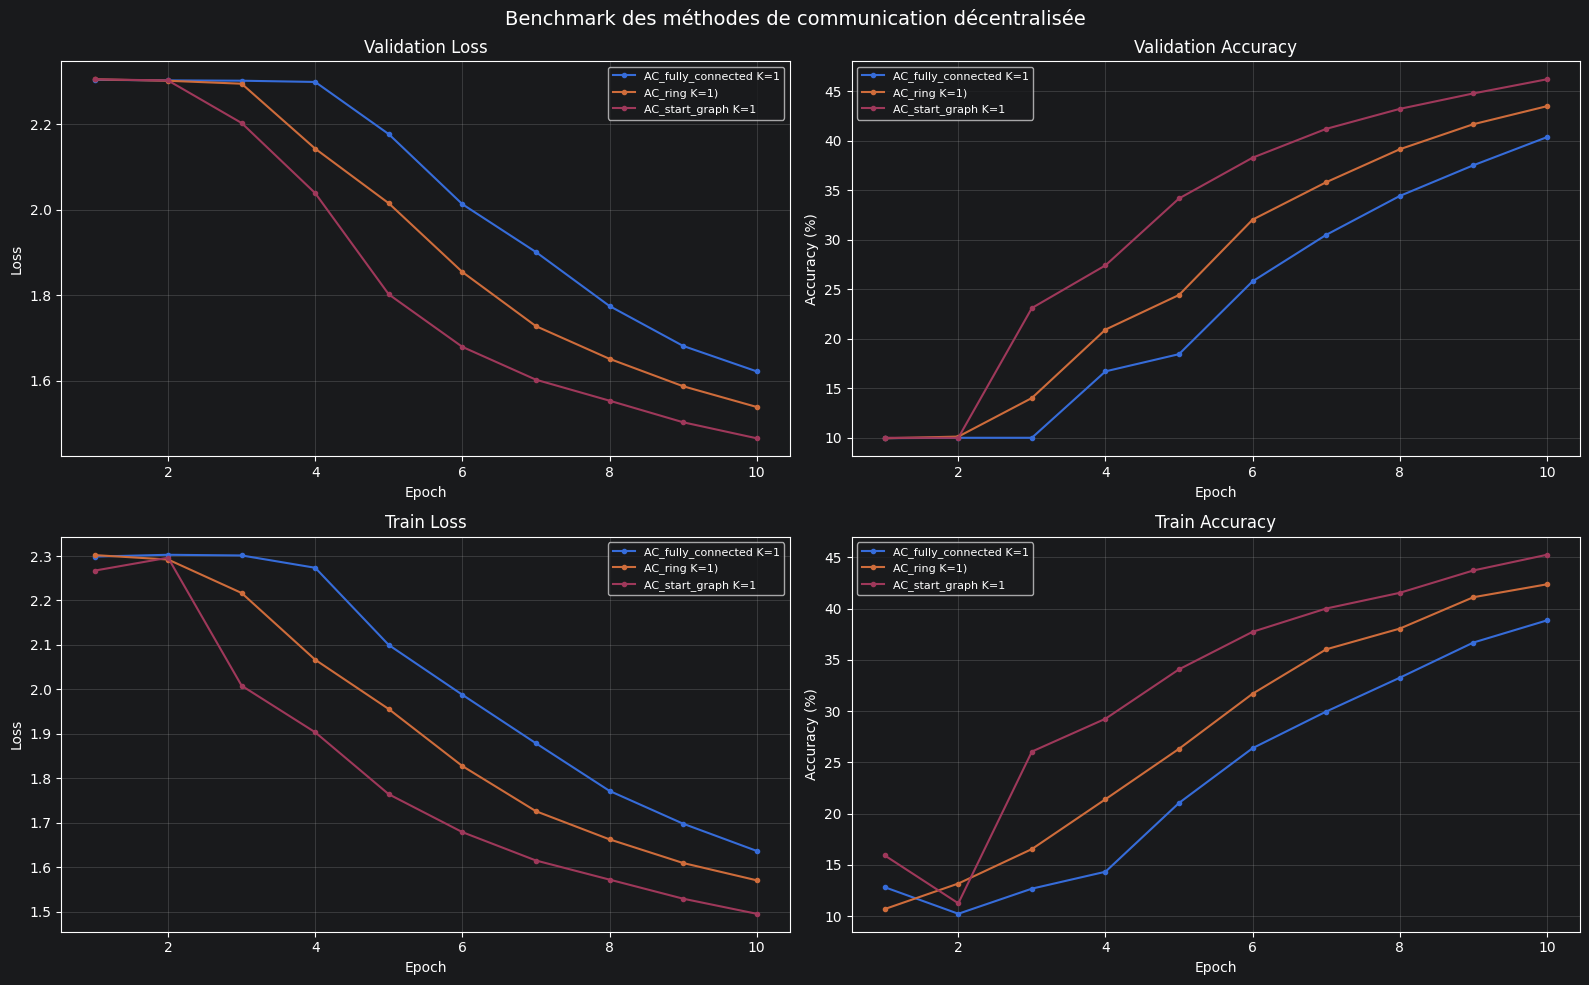

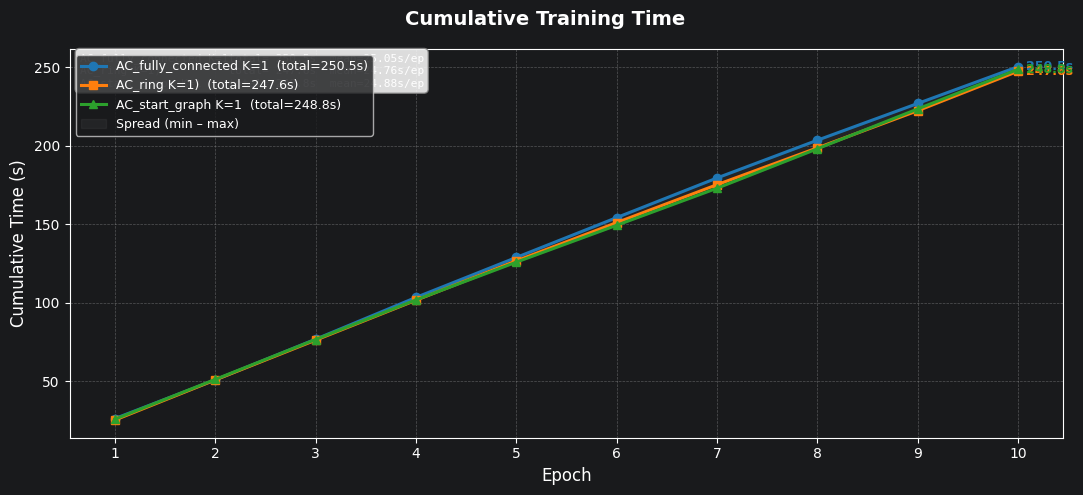

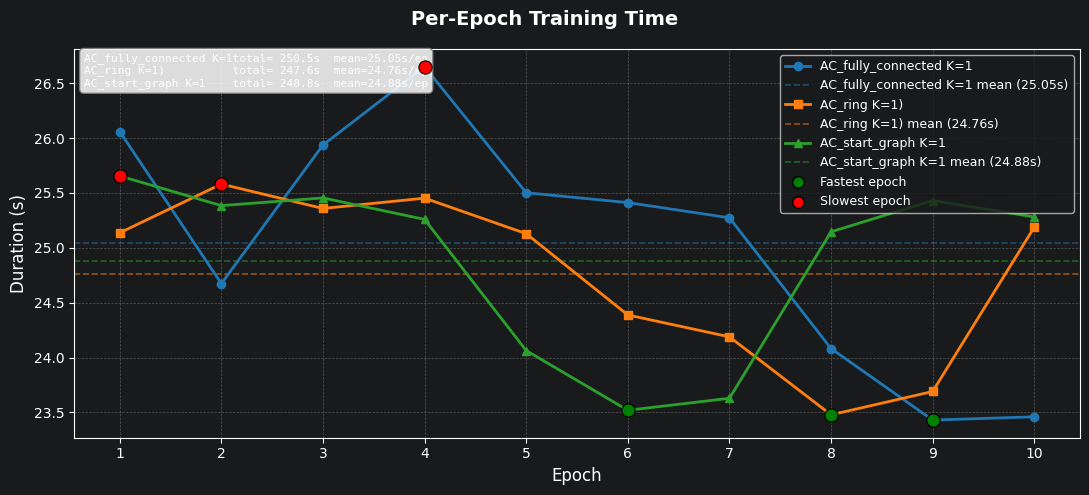


── AC_fully_connected K=1 ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_fully_connected K=1
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 47.307 MB
    Total messages    : 200
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 22.49 ms
    Synchro totale    : 224.9 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


── AC_ring K=1) ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_ring K=1)
──────────────────────────────────────────────────────────
  Agents              : 

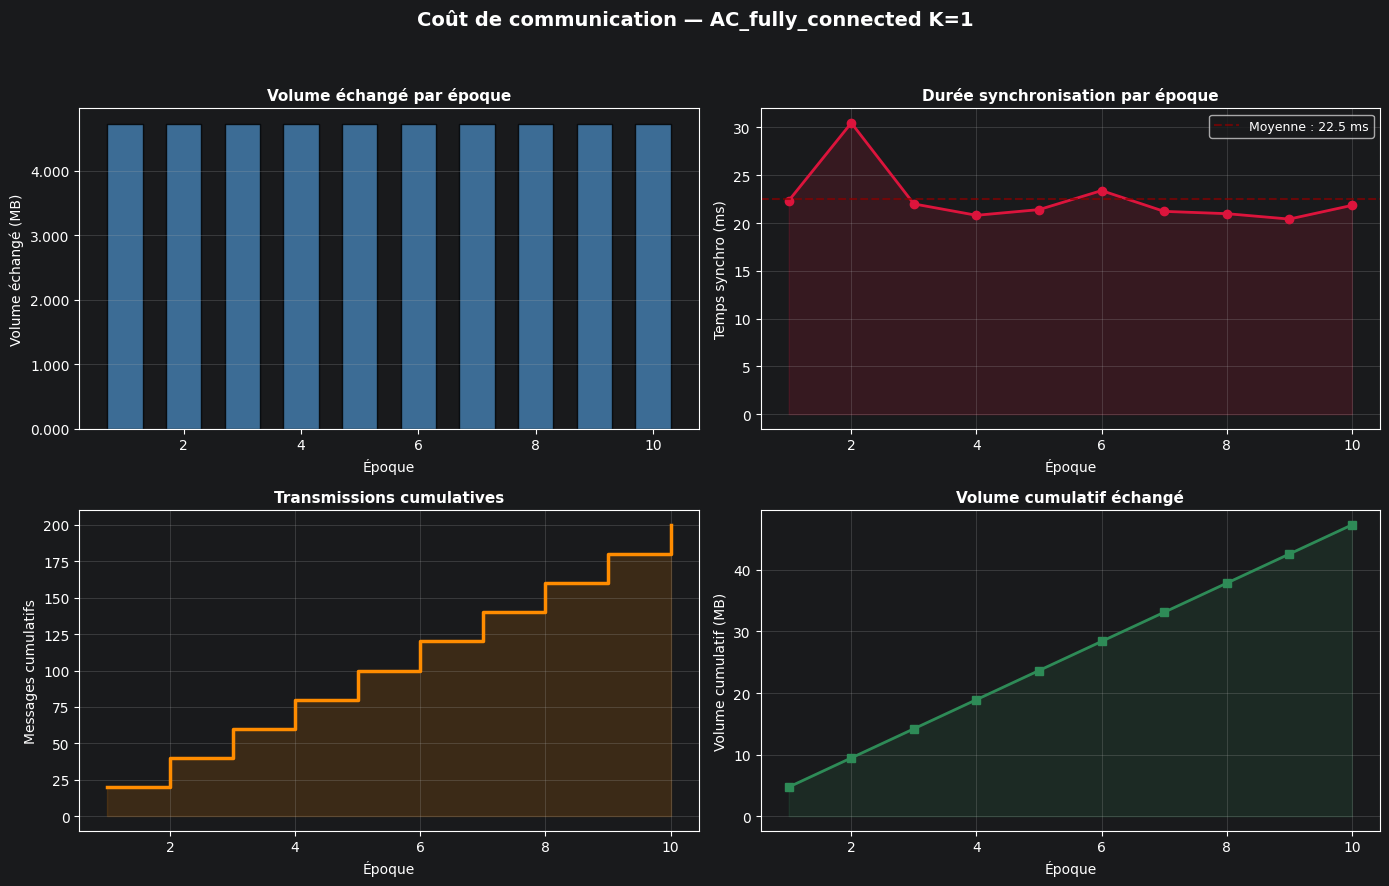


── AC_ring K=1) ──


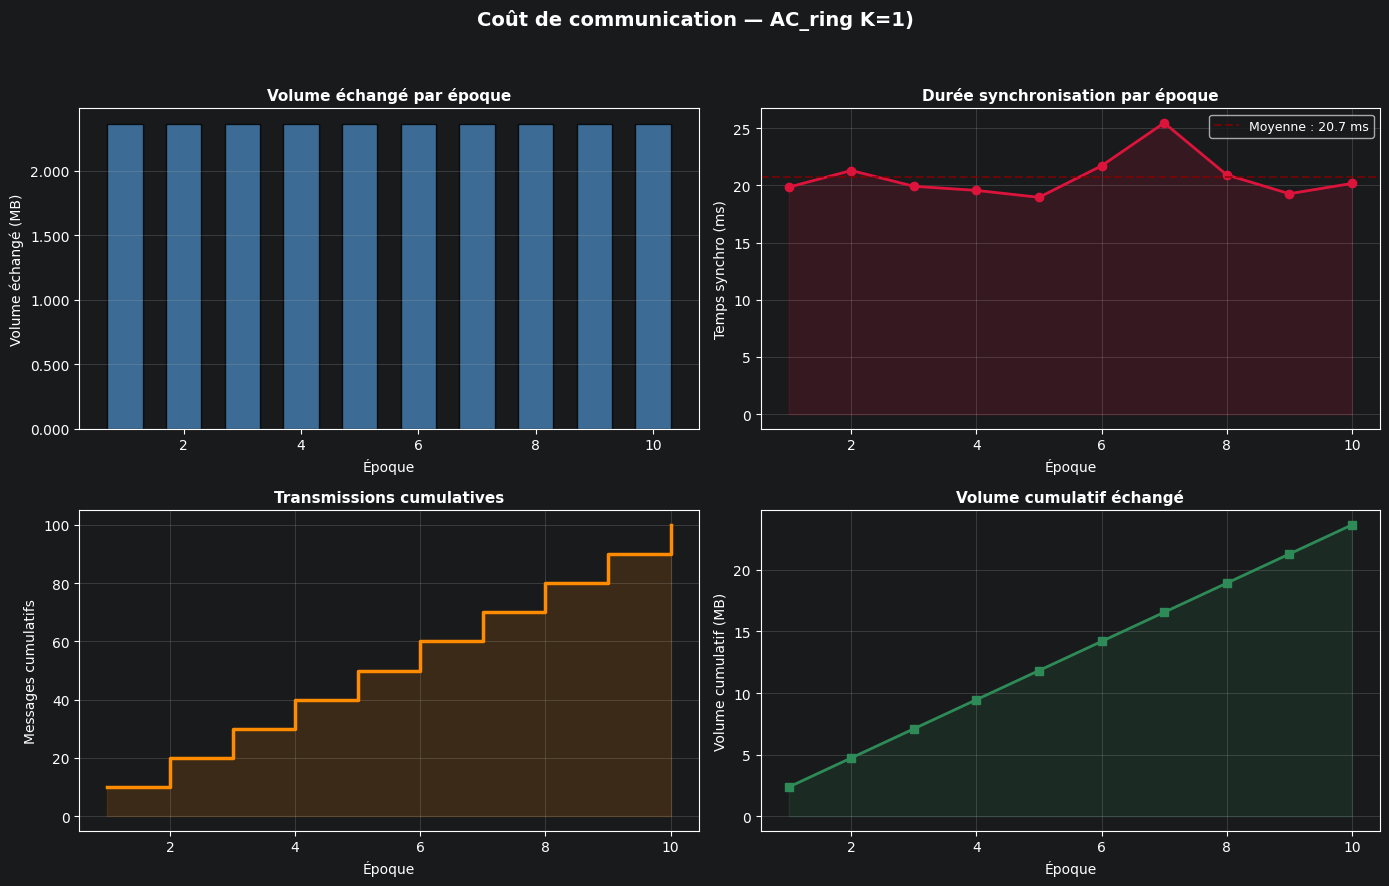


── AC_start_graph K=1 ──


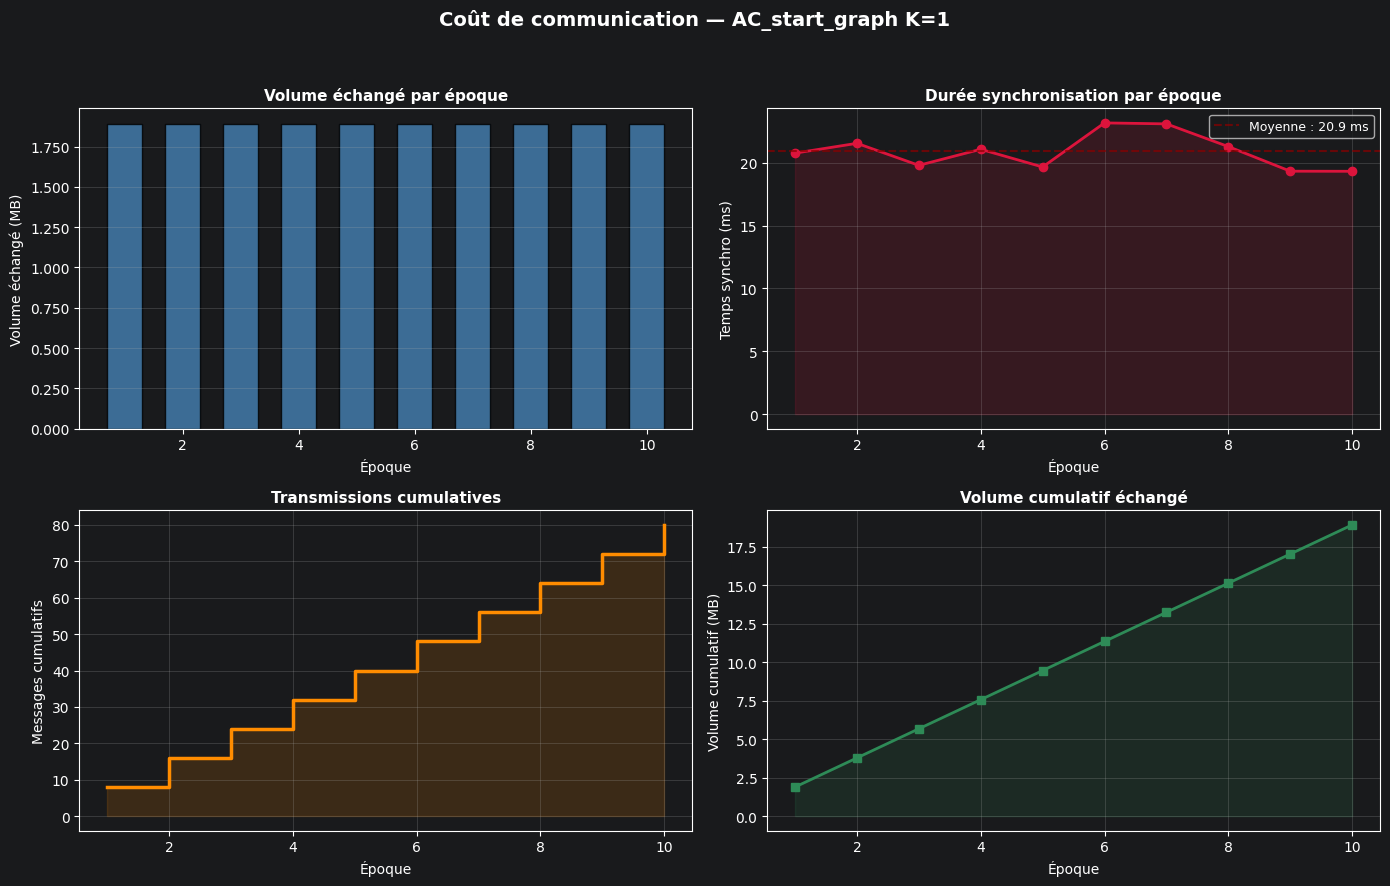


Méthode                          Val Loss    Val Acc  Train Acc
AC_fully_connected K=1             1.6224     40.37%     38.84%
AC_ring K=1)                       1.5392     43.50%     42.36%
AC_start_graph K=1                 1.4660     46.22%     45.24%


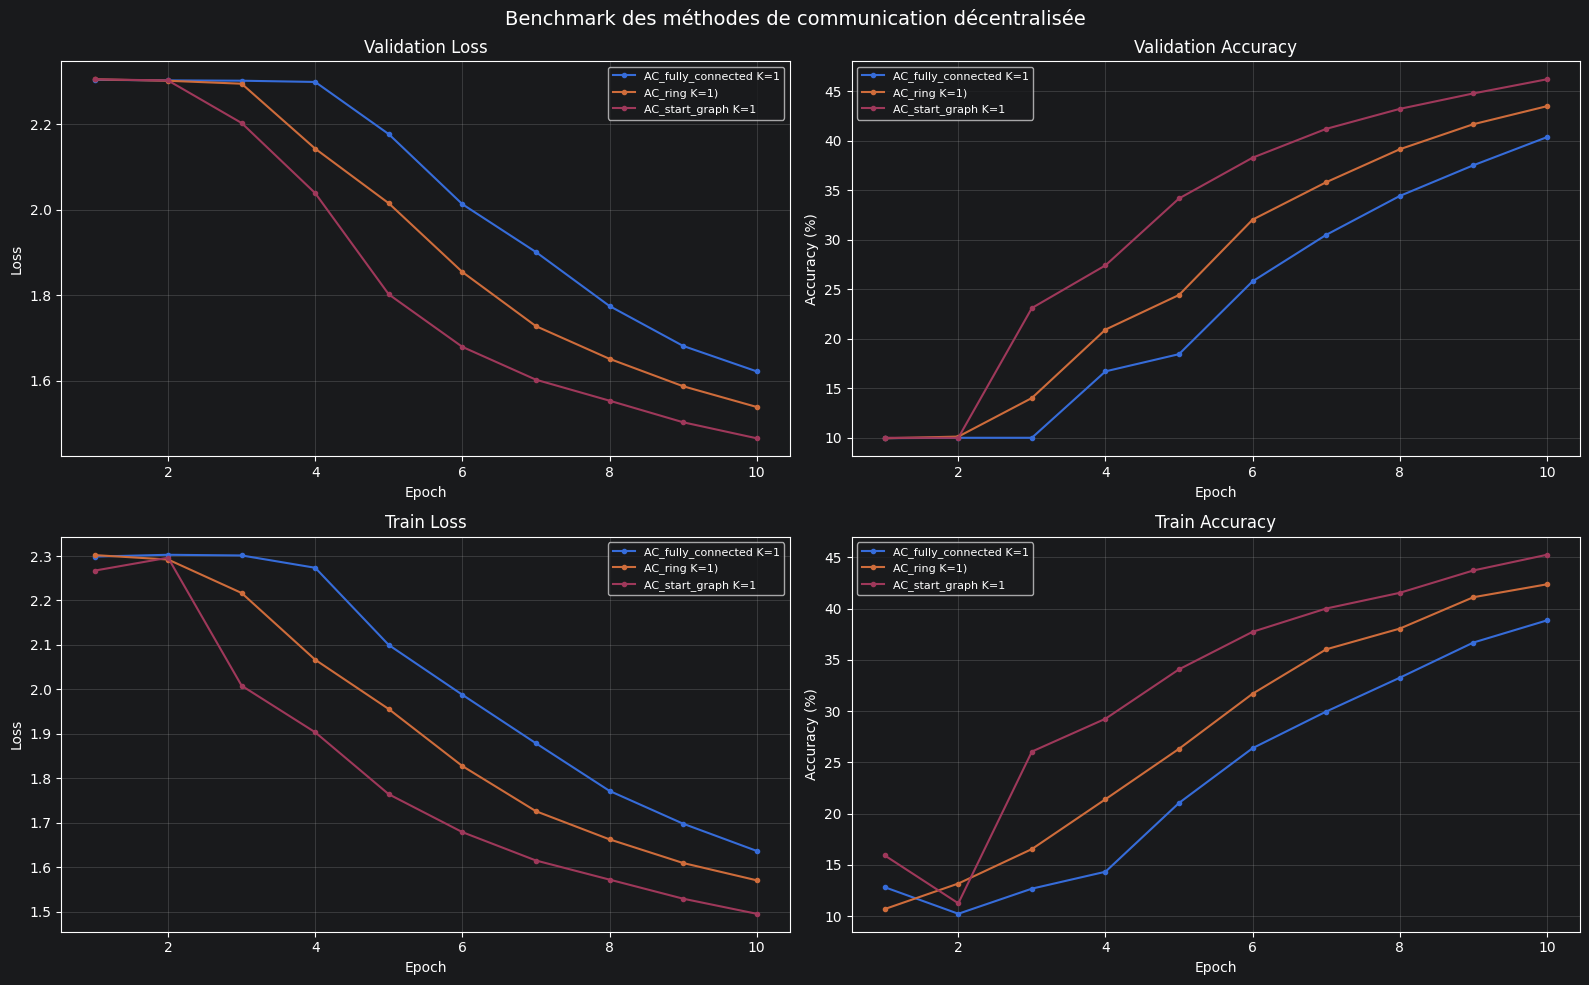

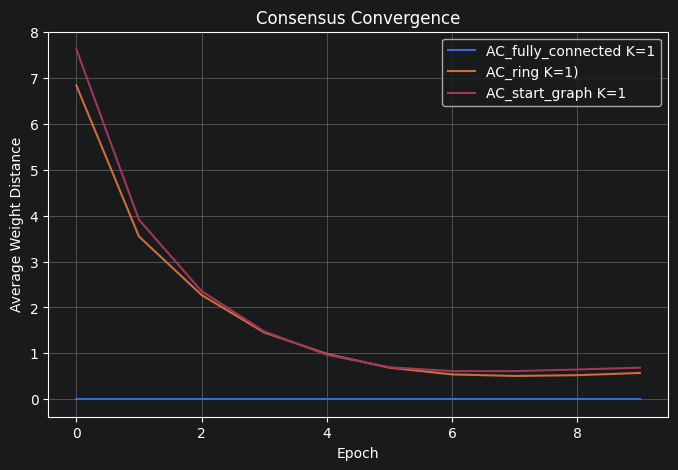

In [3]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 10

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 5
k = 1
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)



def AC_fully_connected_graph_wrapper(agent_list, graph, k, epoch, num_epochs,
                                      comm_cost=None):
    fc_graph = NetworkTopology.fully_connected_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, fc_graph, K=k,
                                  comm_cost=comm_cost)


def AC_ring_graph_wrapper(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.cycle_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, graph, K=k, comm_cost=comm_cost)


def AC_start_graph_wrapper(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    star_graph = NetworkTopology.star_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, star_graph, K=k,
                                  comm_cost=comm_cost)

# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {
    f"AC_fully_connected K={k}"  : AC_fully_connected_graph_wrapper,
    f"AC_ring K={k})"            : AC_ring_graph_wrapper,
    f"AC_start_graph K={k}"      : AC_start_graph_wrapper,
}

results,comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=none,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

# ── Résultats ──────────────────────────────────────────────
comparator.rank()
print_benchmark_summary(results)
plot_all_benchmark_metrics(results)

plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.summary()

for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.plot()


print_benchmark_summary(results)
plot_all_benchmark_metrics(results)
plot_average_distance(results)

0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775

  RUN — méthode : AC_fully_connected K=3
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775
  [Epoch 1/10] threads started …
Agent 4 start
Agent 1 start
Agent 3 start
Agent 2 start
Agent 0 start
Model4 - Acc:11.99 % - Loss:2.297993492126465 %
Model1 - Acc:11.7 % - Loss:2.2998939526081084 %
Model2 - Acc:13.42 % - Loss:2.2967163240909576 %
Model3 - Acc:12.59 % - Loss:2.285965577721596 %
Model0 - Acc:11.7 % - Loss:2.2986423897743227 %
[DEBUG] set_epoch_messages called → 60 messages
    → avrg distance after iteration 1: 0.000000
    → avrg distance after iteration 2: 0.000000
    → avrg distance after iteration 3: 0.000000
[DEBUG] _resolve_n_messages → _epoch_n_messages = 60
[DEBUG] _record epoch=0 → n_messages=60
[DEBUG] _resolve_n_messages → _epoch_n_messages = 60
  [Epoch 1/10] ✓  time=25.09s  cumulative=25.09s
  [Epoch 2/10] threads started …
Agent 0 start
Agent 4 start
Agent 1 start
Agent 2 

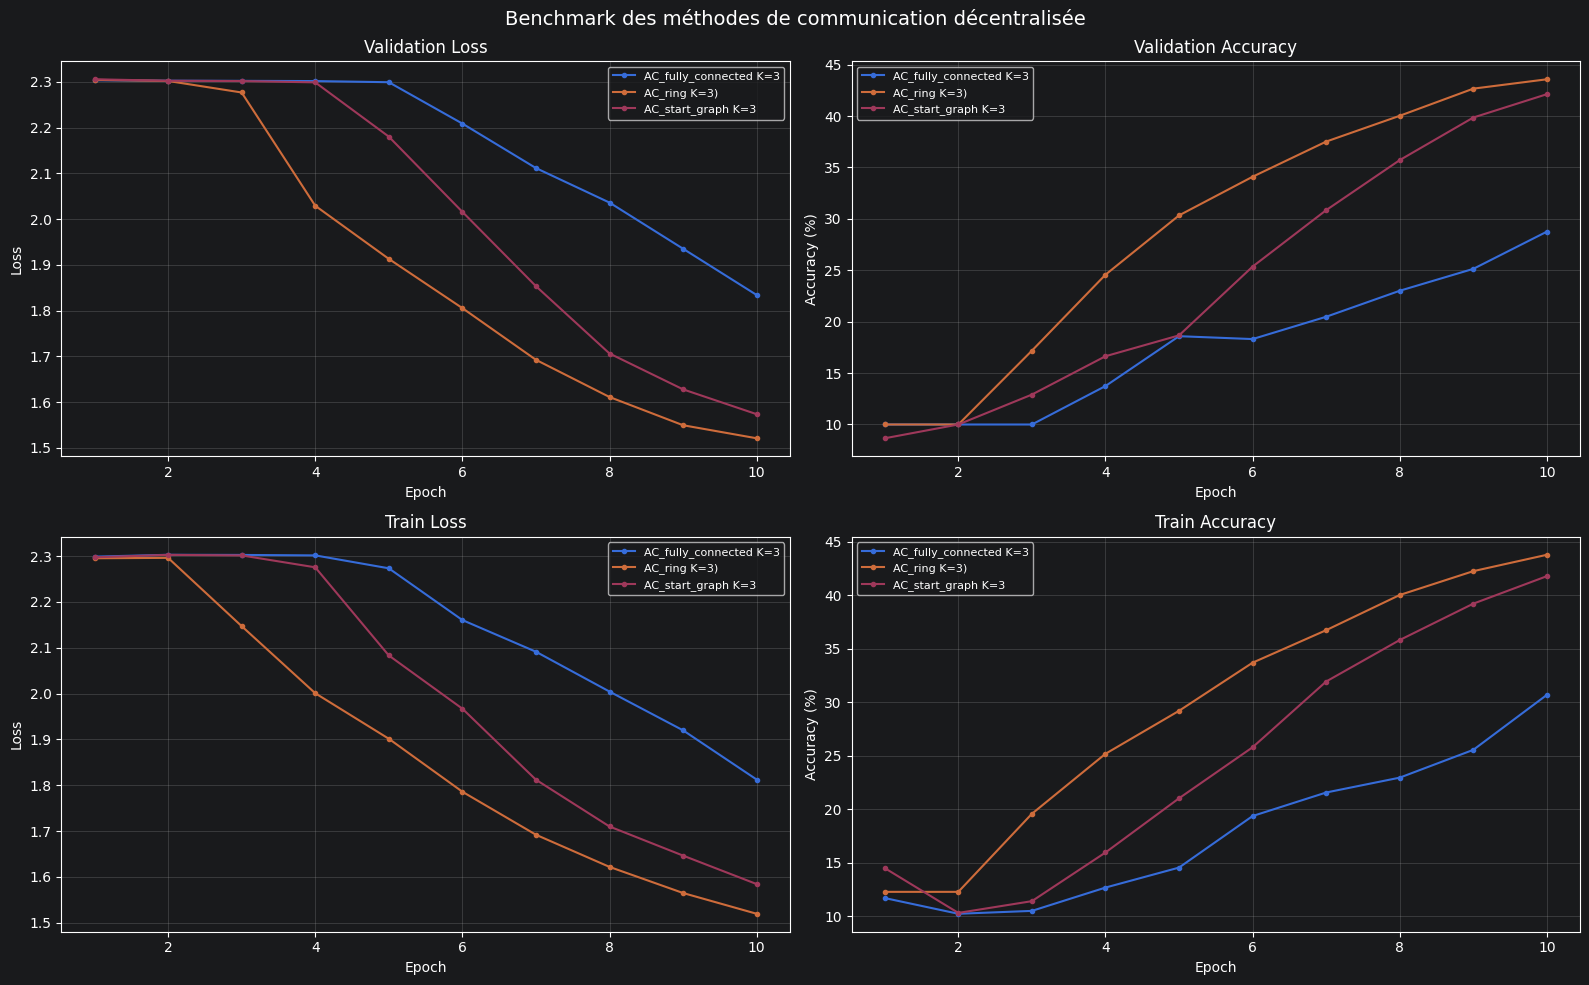

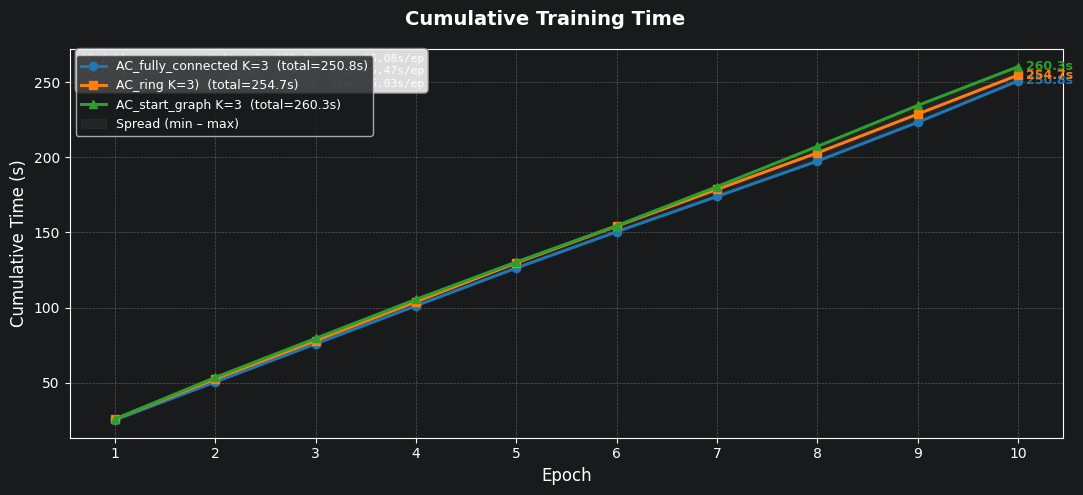

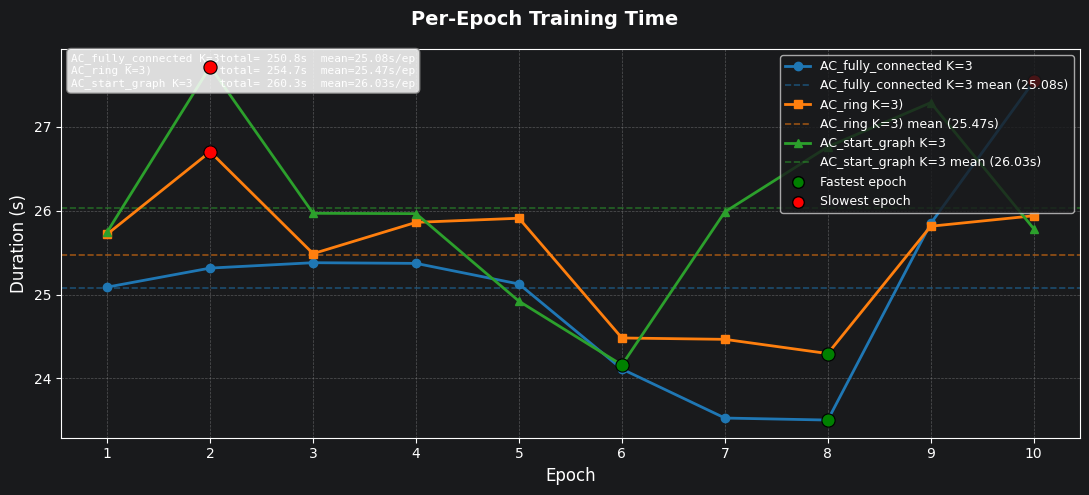


── AC_fully_connected K=3 ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_fully_connected K=3
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 141.920 MB
    Total messages    : 600
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 59.24 ms
    Synchro totale    : 592.4 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


── AC_ring K=3) ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_ring K=3)
──────────────────────────────────────────────────────────
  Agents              :

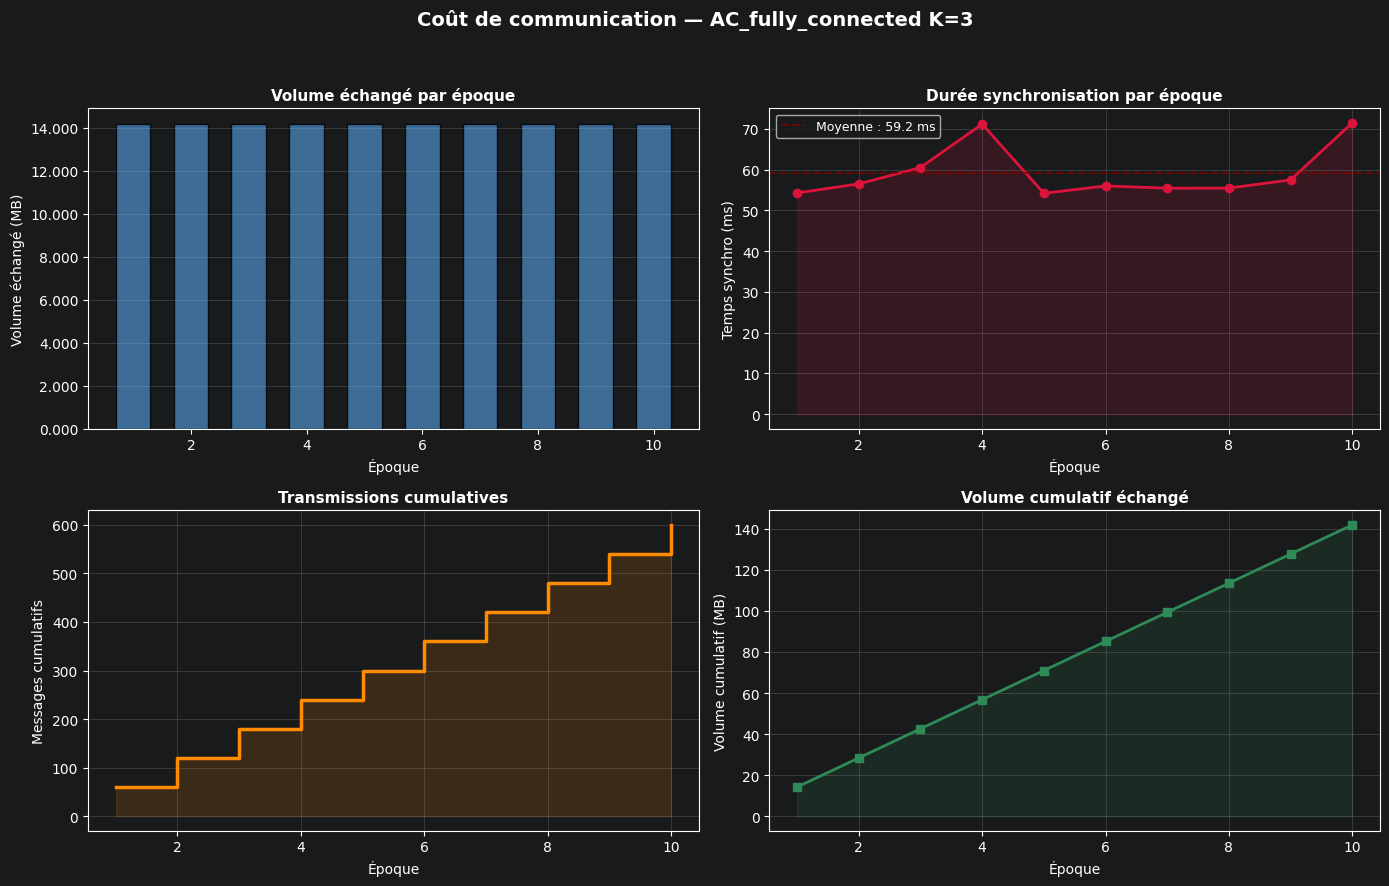


── AC_ring K=3) ──


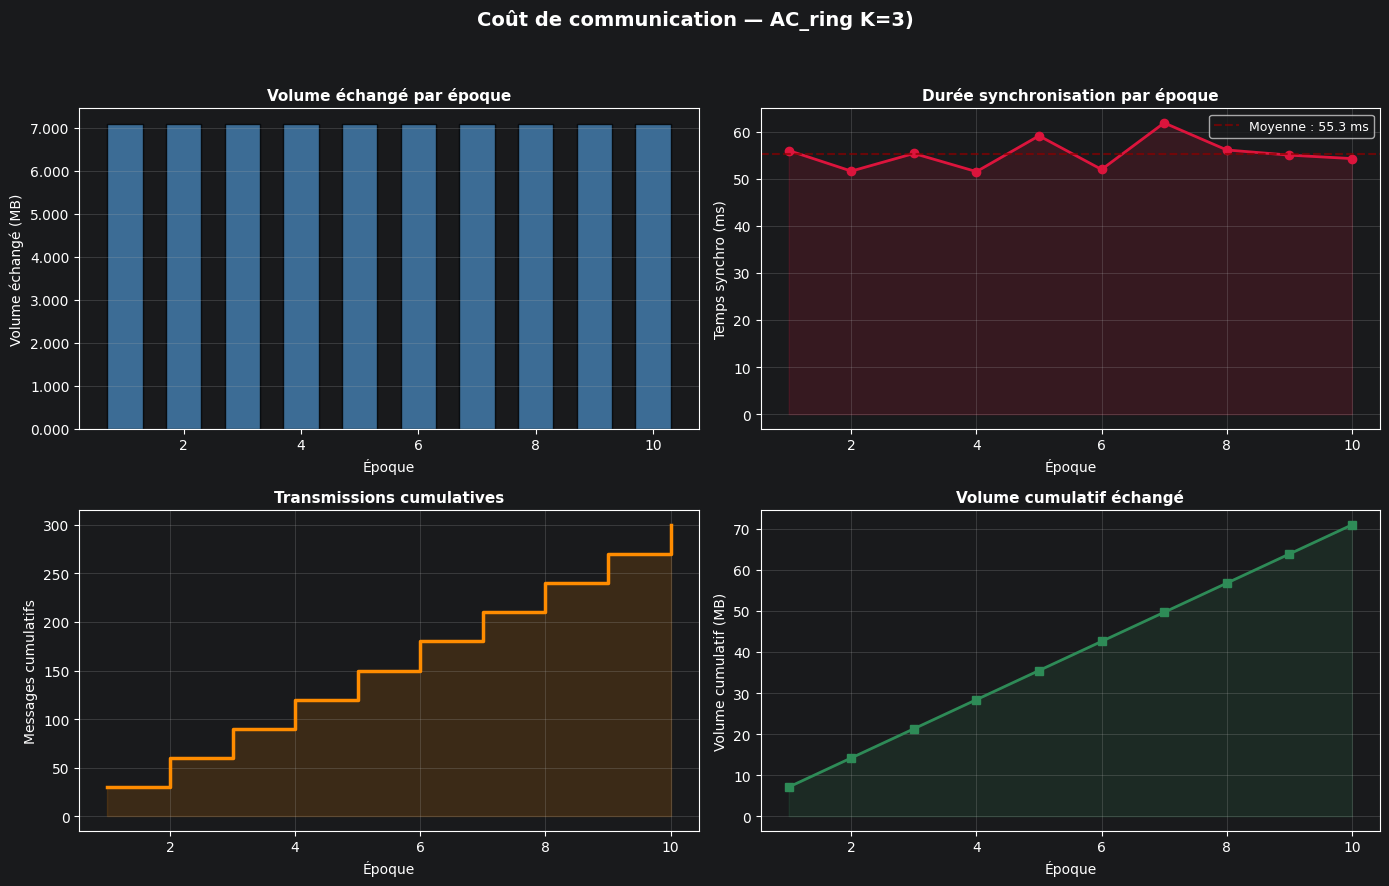


── AC_start_graph K=3 ──


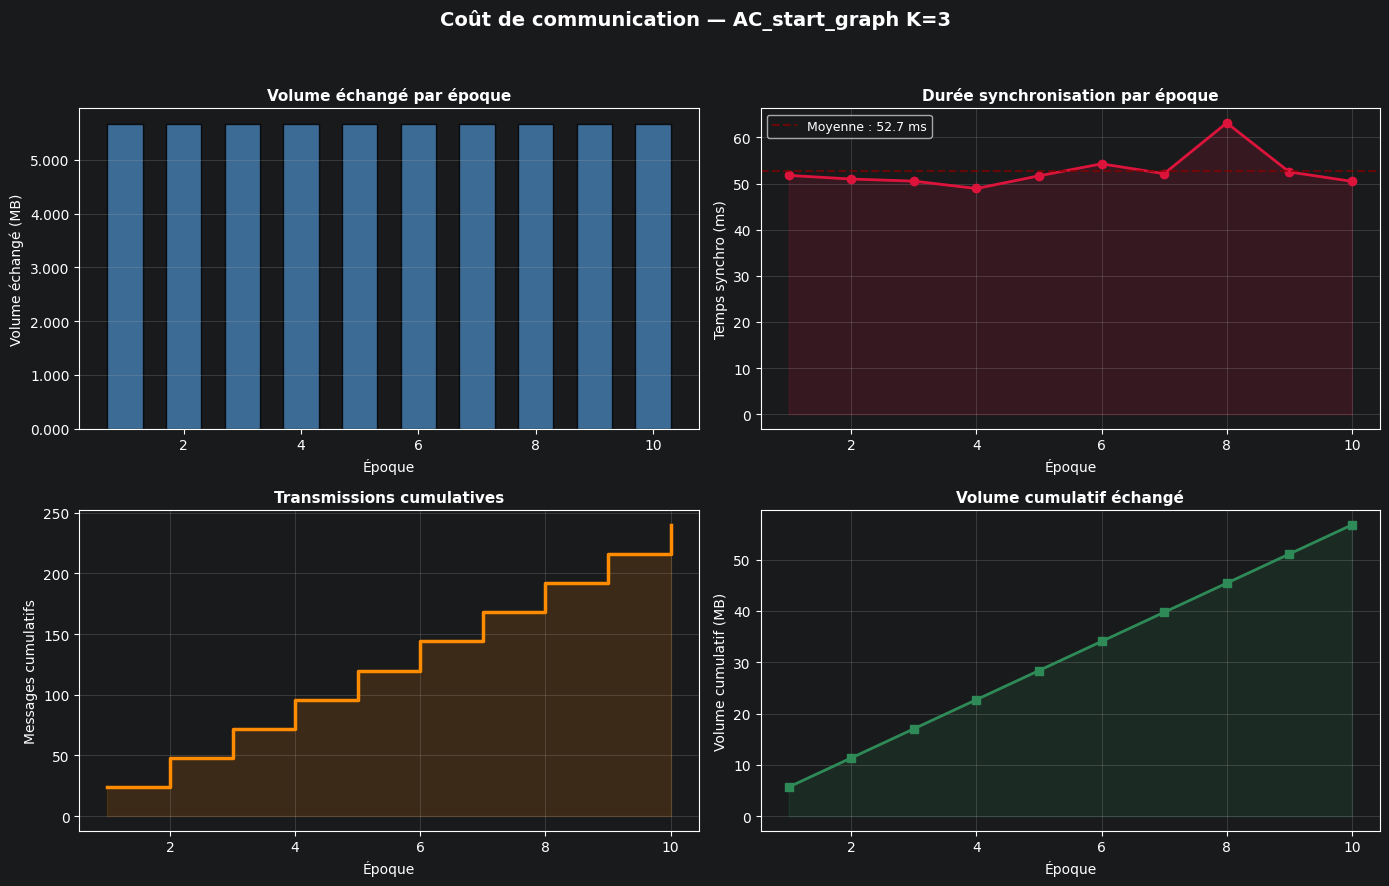


Méthode                          Val Loss    Val Acc  Train Acc
AC_fully_connected K=3             1.8344     28.76%     30.70%
AC_ring K=3)                       1.5212     43.58%     43.80%
AC_start_graph K=3                 1.5738     42.13%     41.80%


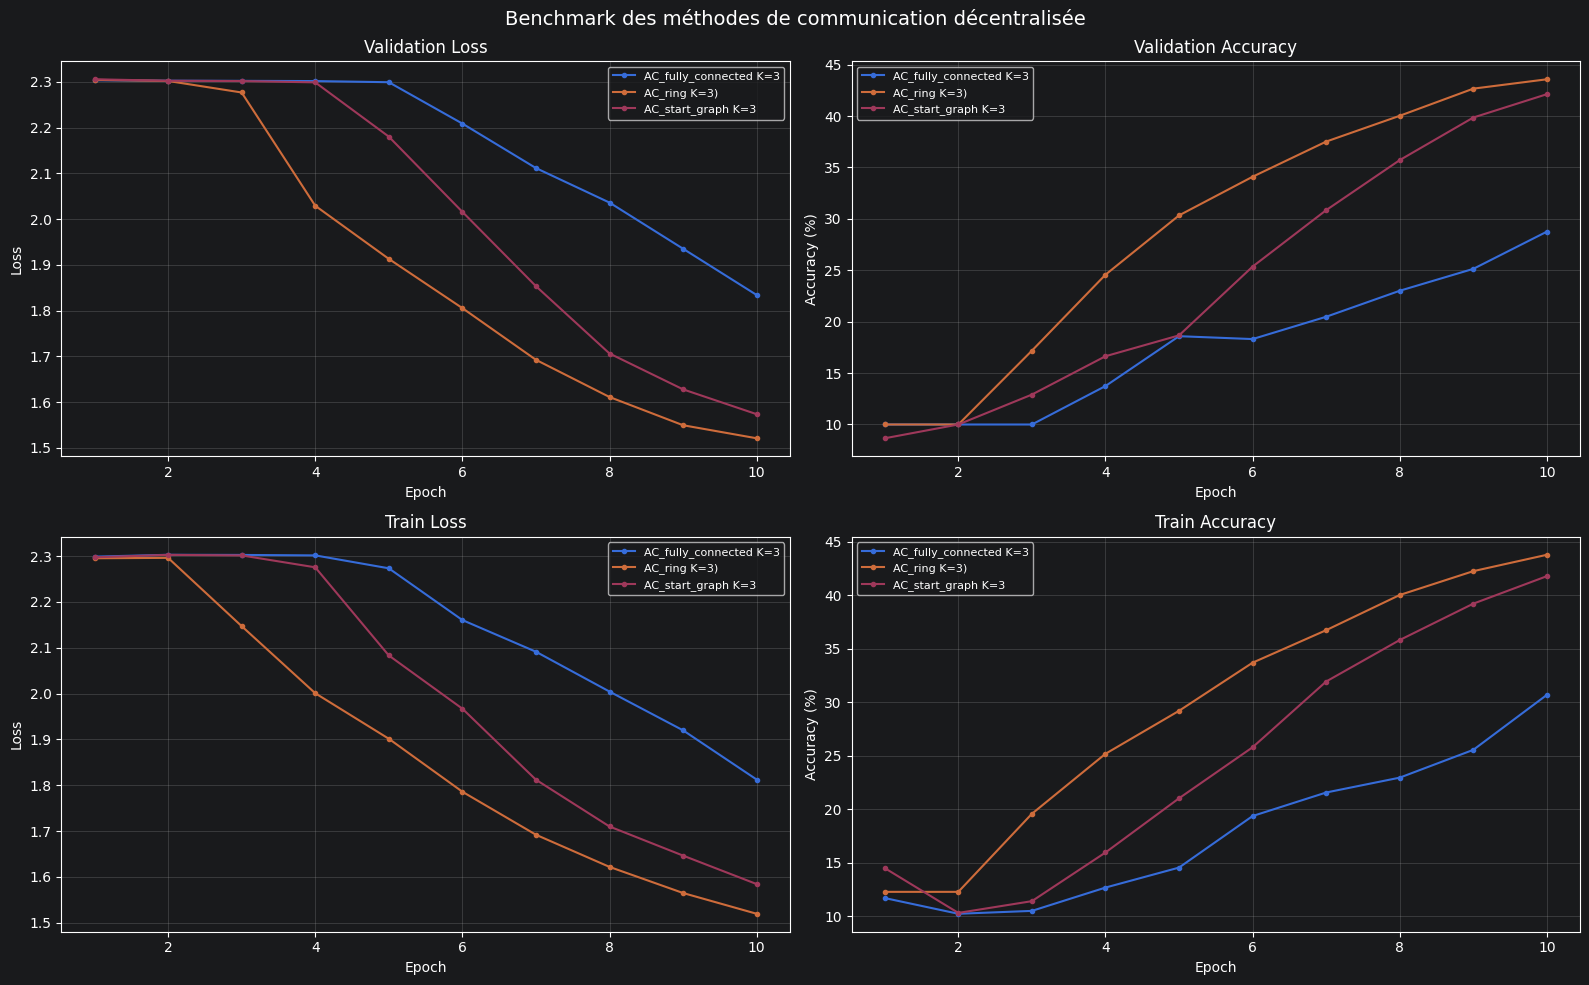

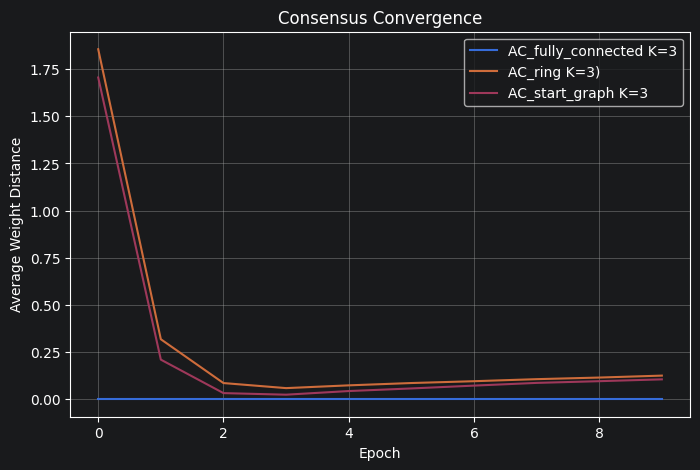

In [4]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 10

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 5
k = 3
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)



def AC_fully_connected_graph_wrapper(agent_list, graph, k, epoch, num_epochs,
                                      comm_cost=None):
    fc_graph = NetworkTopology.fully_connected_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, fc_graph, K=k,
                                  comm_cost=comm_cost)


def AC_ring_graph_wrapper(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.cycle_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, graph, K=k, comm_cost=comm_cost)


def AC_start_graph_wrapper(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    star_graph = NetworkTopology.star_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, star_graph, K=k,
                                  comm_cost=comm_cost)

# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {
    f"AC_fully_connected K={k}"  : AC_fully_connected_graph_wrapper,
    f"AC_ring K={k})"            : AC_ring_graph_wrapper,
    f"AC_start_graph K={k}"      : AC_start_graph_wrapper,
}

results,comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=none,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

# ── Résultats ──────────────────────────────────────────────
comparator.rank()
print_benchmark_summary(results)
plot_all_benchmark_metrics(results)

plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.summary()

for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.plot()


print_benchmark_summary(results)
plot_all_benchmark_metrics(results)
plot_average_distance(results)

0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775

  RUN — méthode : AC_fully_connected K=5
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775
  [Epoch 1/10] threads started …
Agent 1 start
Agent 4 start
Agent 2 start
Agent 3 start
Agent 0 start
Model1 - Acc:11.25 % - Loss:2.2946844749450683 %
Model2 - Acc:12.42 % - Loss:2.297875911474228 %
Model3 - Acc:16.1 % - Loss:2.2726889457702635 %
Model0 - Acc:17.03 % - Loss:2.2671714717149736 %
Model4 - Acc:12.69 % - Loss:2.295253241062164 %
[DEBUG] set_epoch_messages called → 100 messages
    → avrg distance after iteration 1: 0.000000
    → avrg distance after iteration 2: 0.000000
    → avrg distance after iteration 3: 0.000000
    → avrg distance after iteration 4: 0.000000
    → avrg distance after iteration 5: 0.000000
[DEBUG] _resolve_n_messages → _epoch_n_messages = 100
[DEBUG] _record epoch=0 → n_messages=100
[DEBUG] _resolve_n_messages → _epoch_n_messages = 100
  [Epoch 1/10] ✓  time=26.55s  

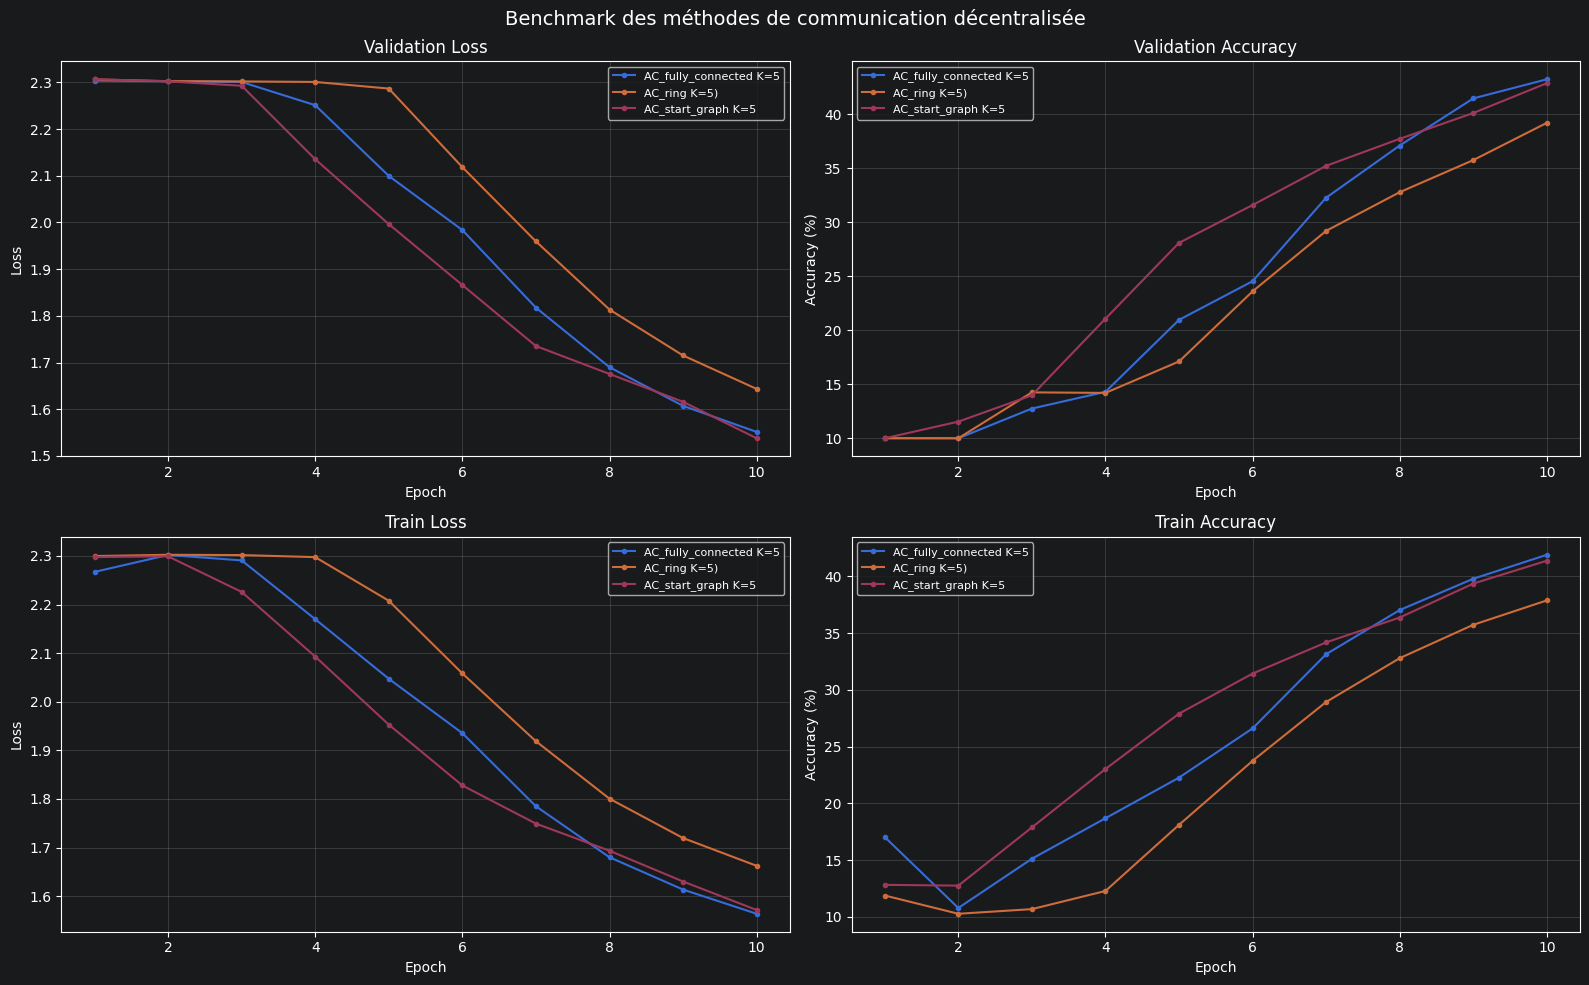

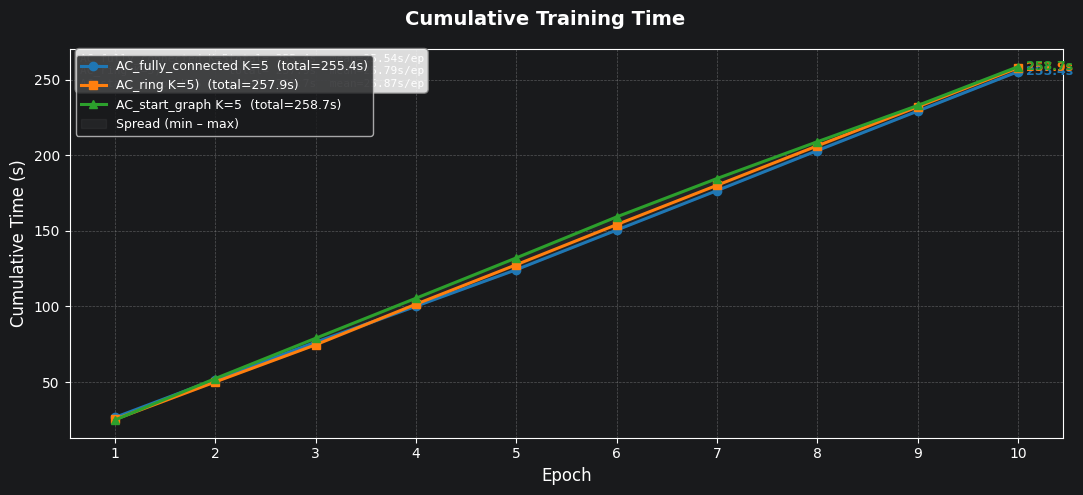

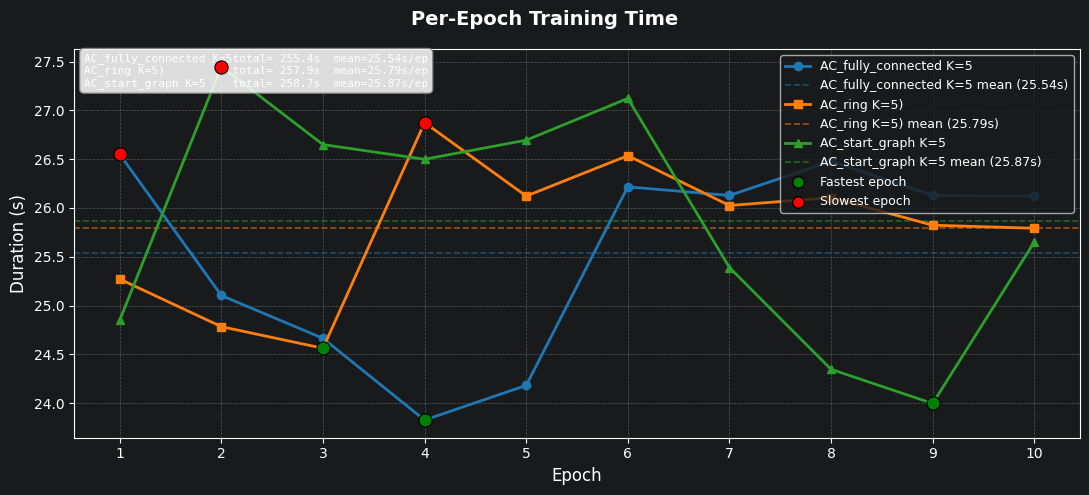


── AC_fully_connected K=5 ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_fully_connected K=5
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 236.534 MB
    Total messages    : 1,000
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 96.56 ms
    Synchro totale    : 965.6 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


── AC_ring K=5) ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_ring K=5)
──────────────────────────────────────────────────────────
  Agents             

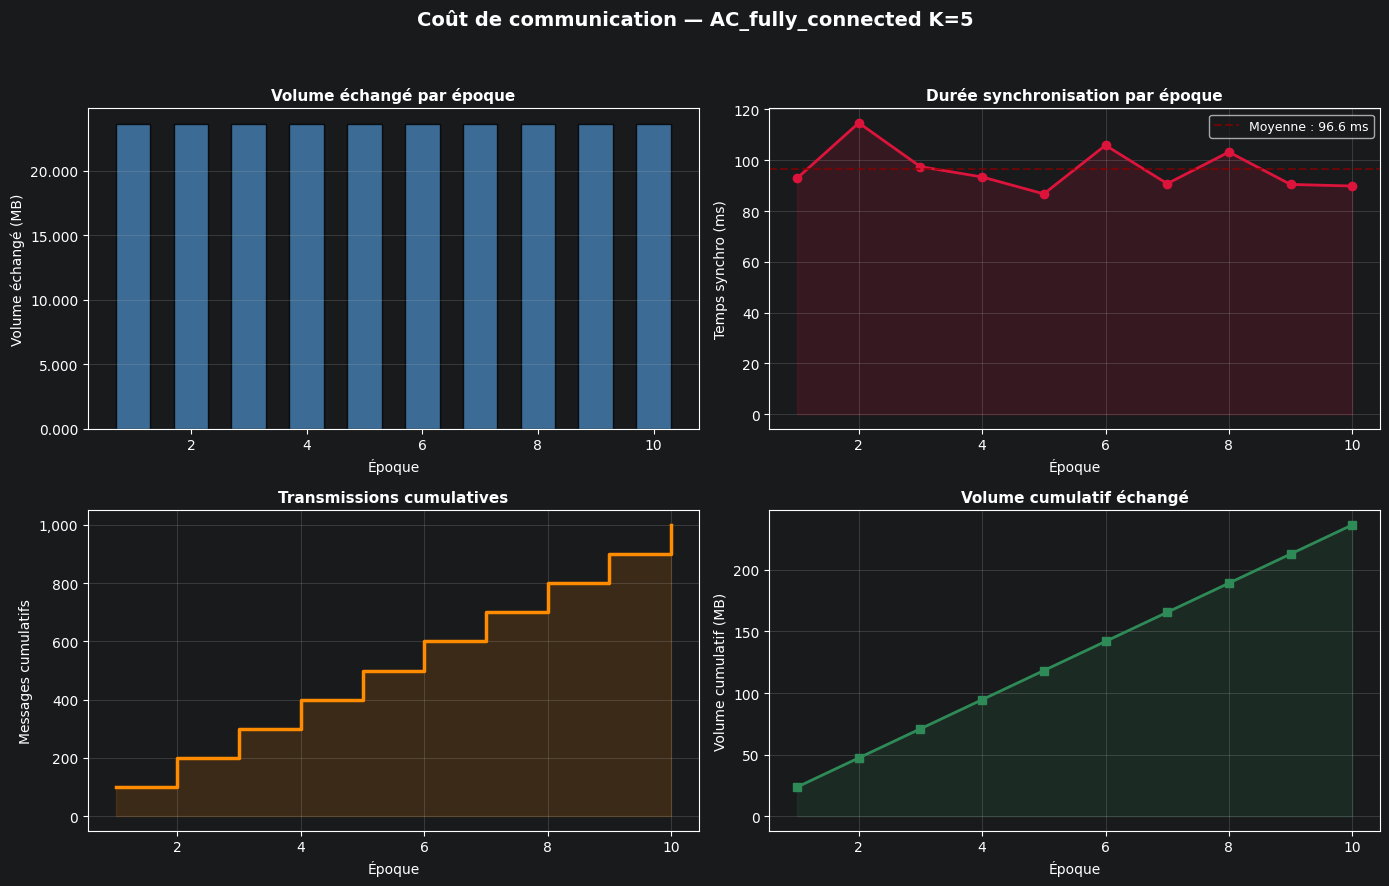


── AC_ring K=5) ──


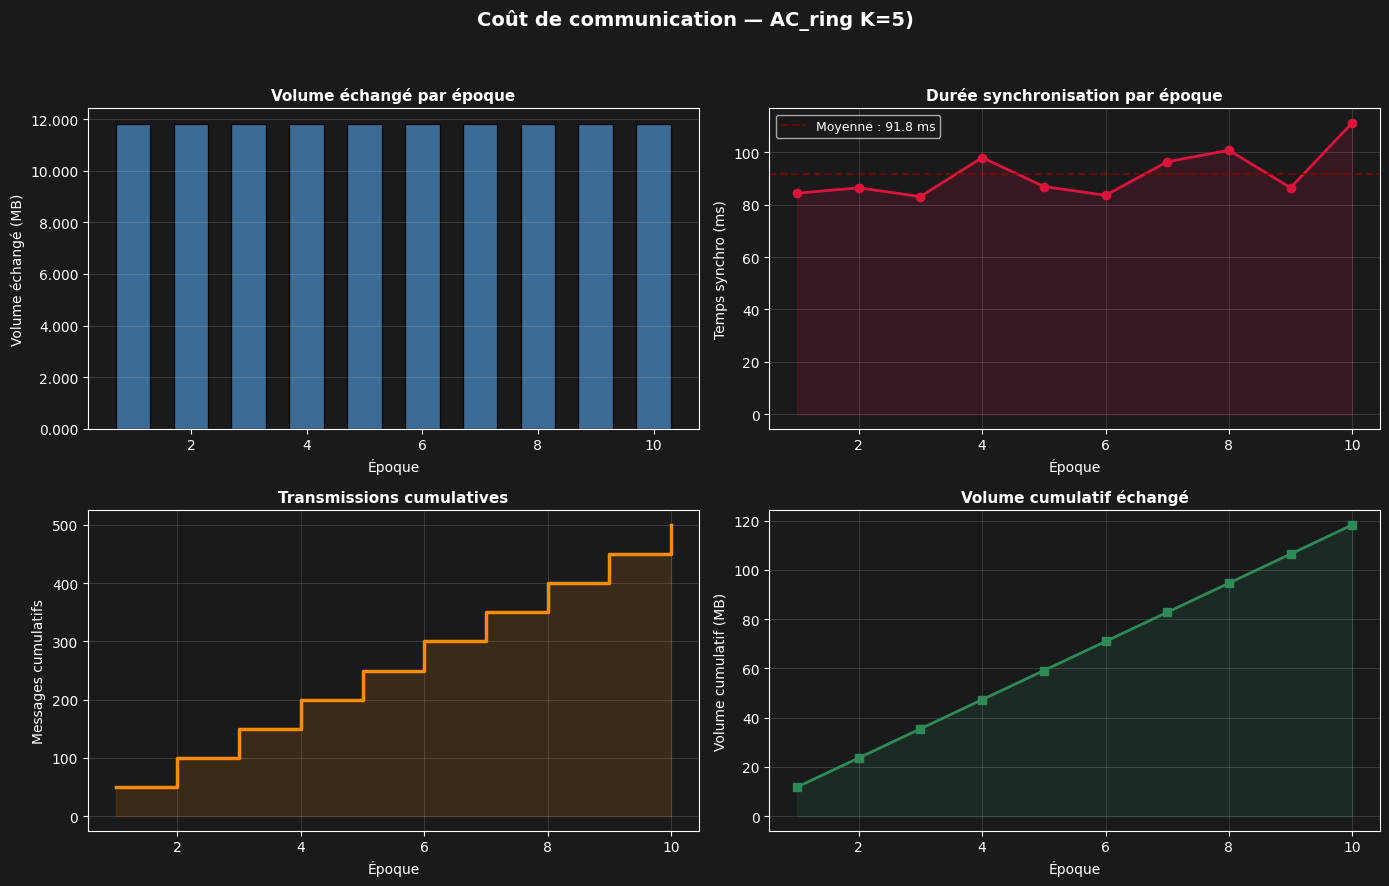


── AC_start_graph K=5 ──


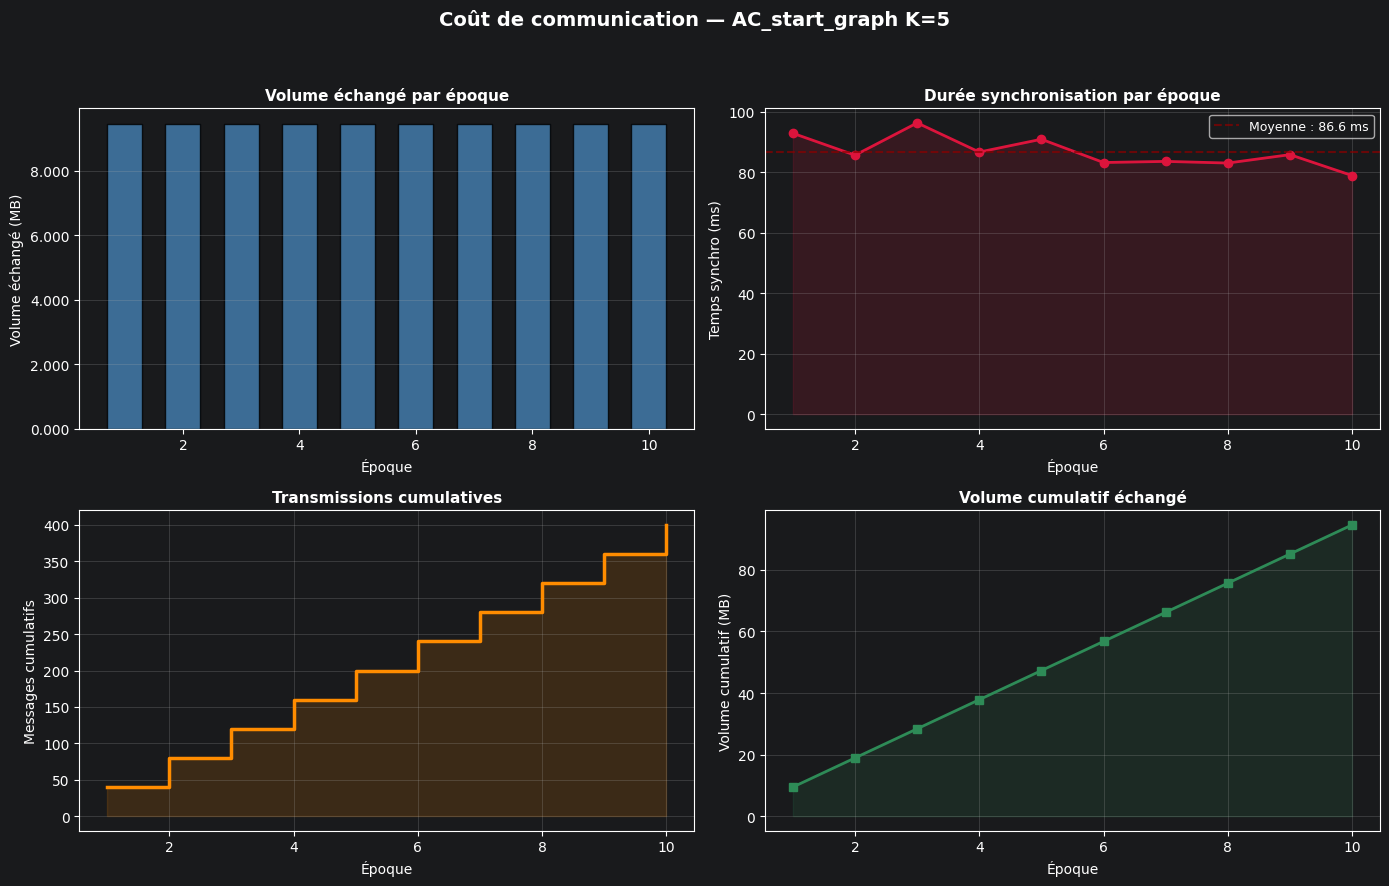


Méthode                          Val Loss    Val Acc  Train Acc
AC_fully_connected K=5             1.5514     43.23%     41.91%
AC_ring K=5)                       1.6435     39.20%     37.89%
AC_start_graph K=5                 1.5377     42.87%     41.39%


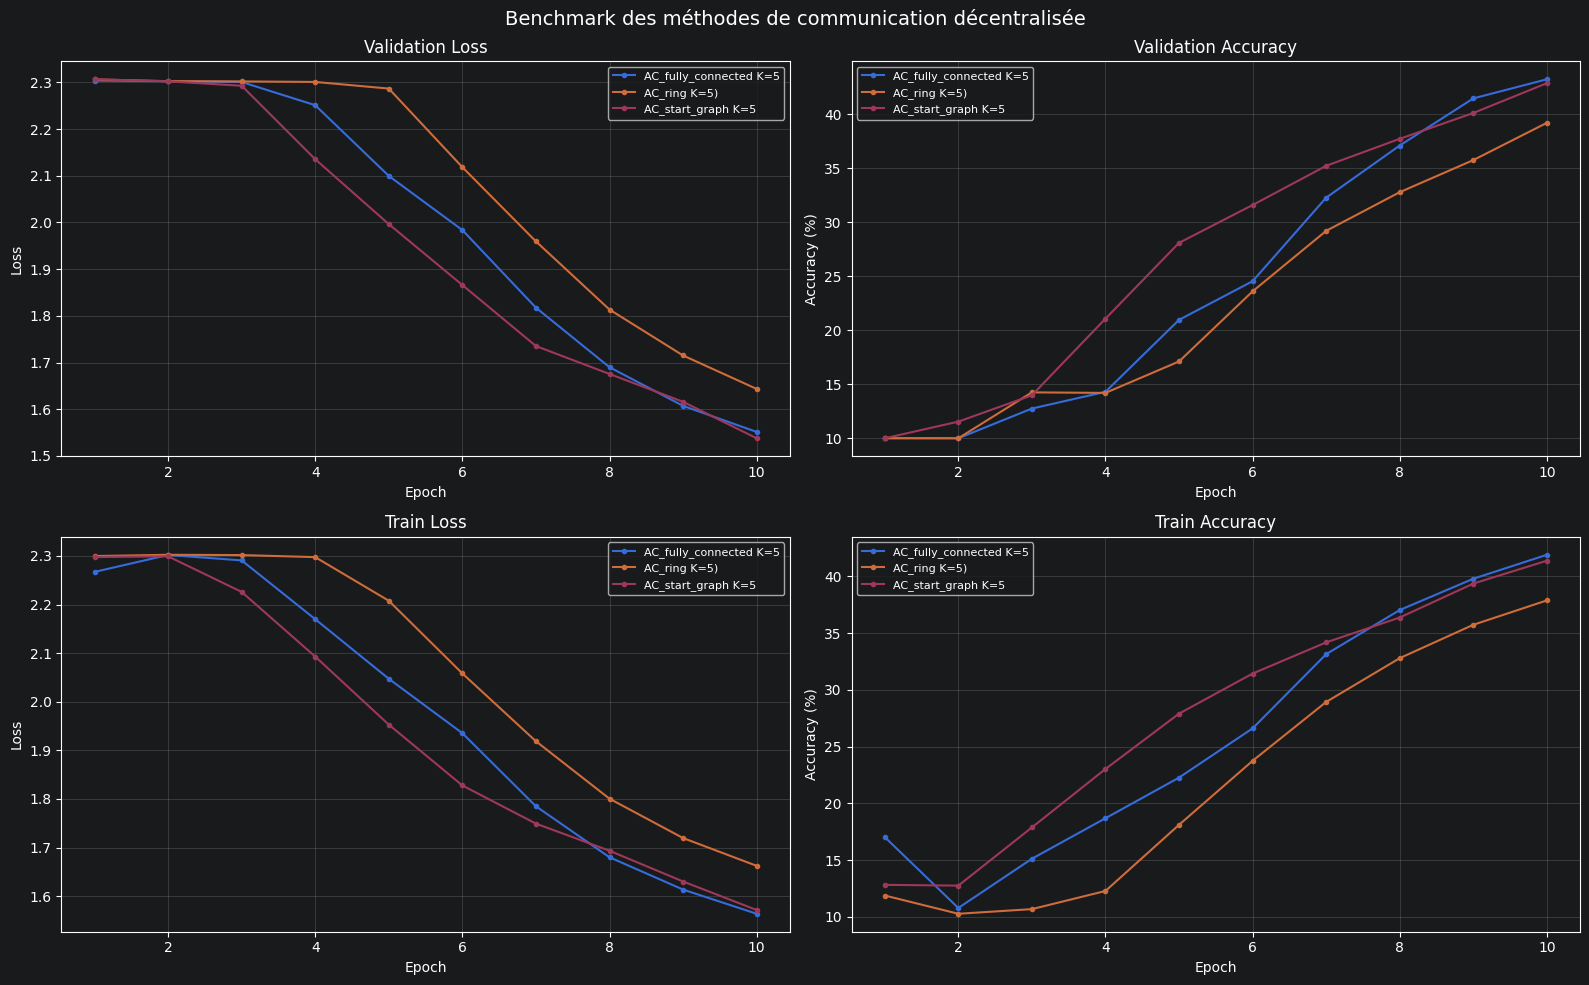

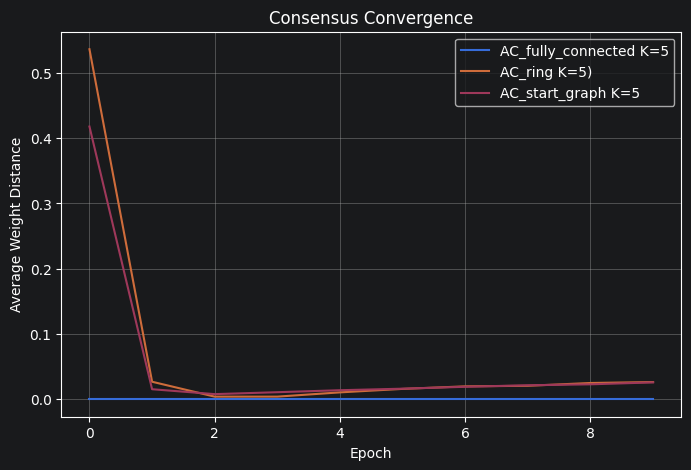

In [5]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 10

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 5
k = 5
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)



def AC_fully_connected_graph_wrapper(agent_list, graph, k, epoch, num_epochs,
                                      comm_cost=None):
    fc_graph = NetworkTopology.fully_connected_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, fc_graph, K=k,
                                  comm_cost=comm_cost)


def AC_ring_graph_wrapper(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.cycle_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, graph, K=k, comm_cost=comm_cost)


def AC_start_graph_wrapper(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    star_graph = NetworkTopology.star_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, star_graph, K=k,
                                  comm_cost=comm_cost)

# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {
    f"AC_fully_connected K={k}"  : AC_fully_connected_graph_wrapper,
    f"AC_ring K={k})"            : AC_ring_graph_wrapper,
    f"AC_start_graph K={k}"      : AC_start_graph_wrapper,
}

results,comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=none,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

# ── Résultats ──────────────────────────────────────────────
comparator.rank()
print_benchmark_summary(results)
plot_all_benchmark_metrics(results)

plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.summary()

for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.plot()


print_benchmark_summary(results)
plot_all_benchmark_metrics(results)
plot_average_distance(results)

0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775

  RUN — méthode : AC_fully_connected K=7
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775
  [Epoch 1/10] threads started …
Agent 2 start
Agent 3 start
Agent 0 start
Agent 1 start
Agent 4 start
Model2 - Acc:13.46 % - Loss:2.28698988032341 %
Model3 - Acc:12.39 % - Loss:2.2831028141975405 %
Model0 - Acc:15.58 % - Loss:2.2500608040094376 %
Model4 - Acc:14.92 % - Loss:2.292704164266586 %
Model1 - Acc:12.18 % - Loss:2.2844573891162874 %
[DEBUG] set_epoch_messages called → 140 messages
    → avrg distance after iteration 1: 0.000000
    → avrg distance after iteration 2: 0.000000
    → avrg distance after iteration 3: 0.000000
    → avrg distance after iteration 4: 0.000000
    → avrg distance after iteration 5: 0.000000
    → avrg distance after iteration 6: 0.000000
    → avrg distance after iteration 7: 0.000000
[DEBUG] _resolve_n_messages → _epoch_n_messages = 140
[DEBUG] _record epoch=0 → n_me

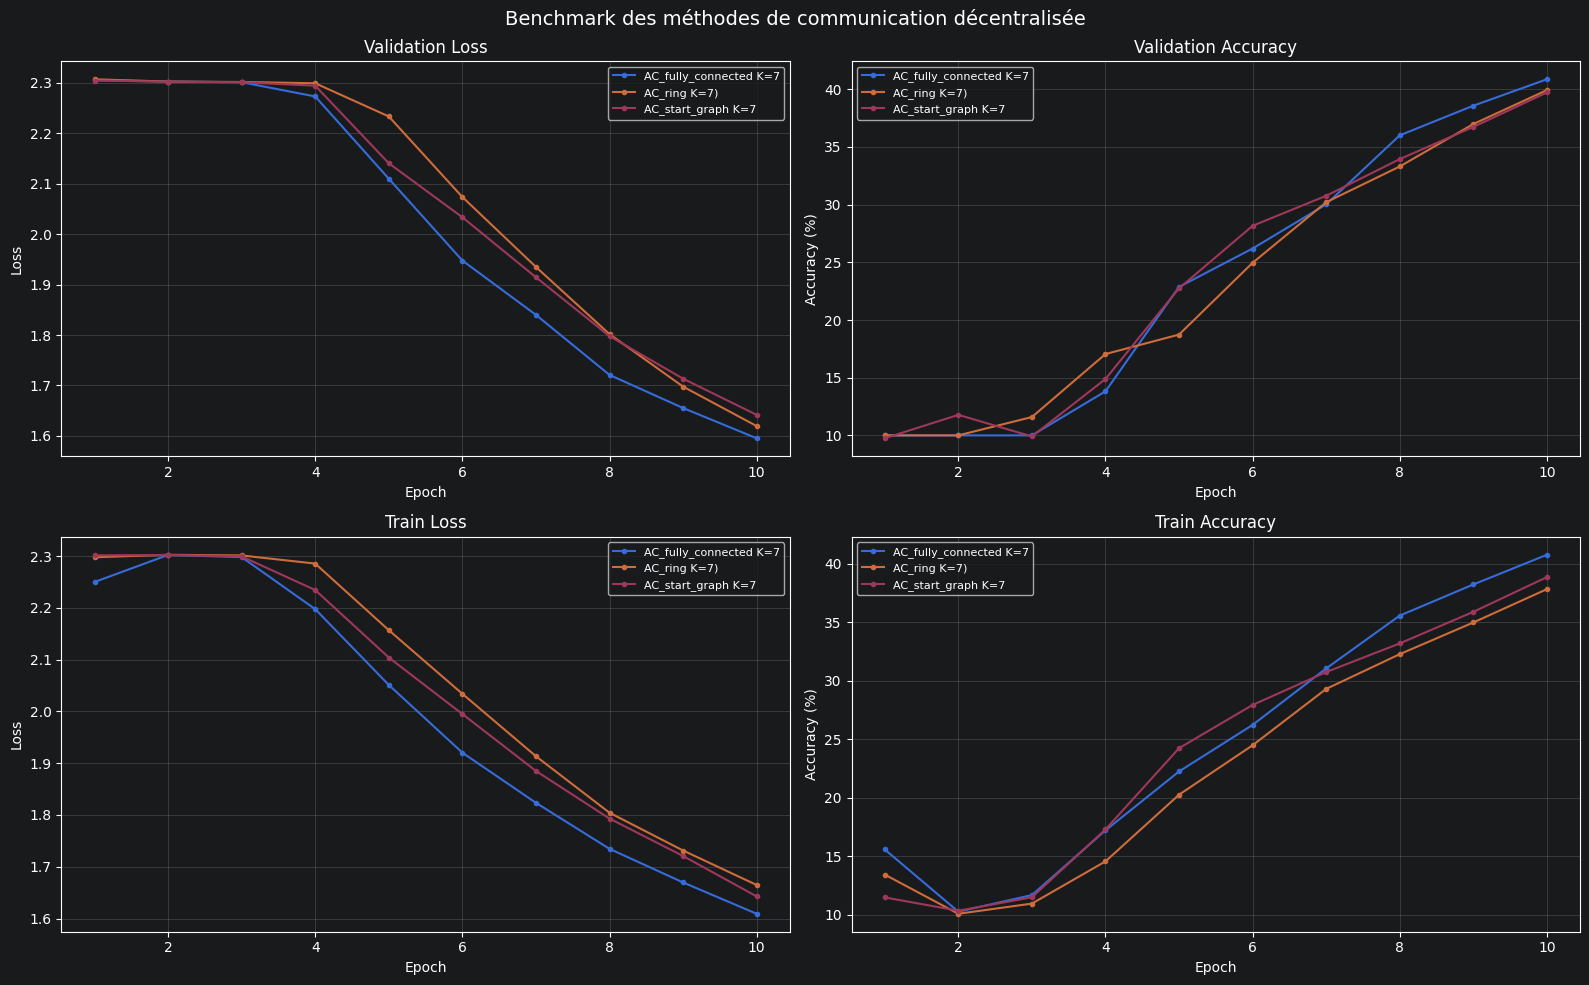

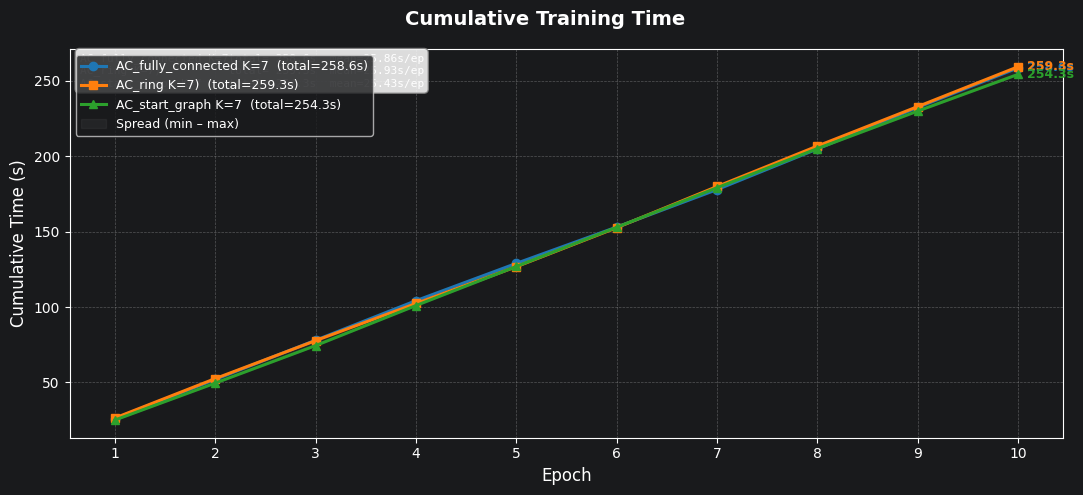

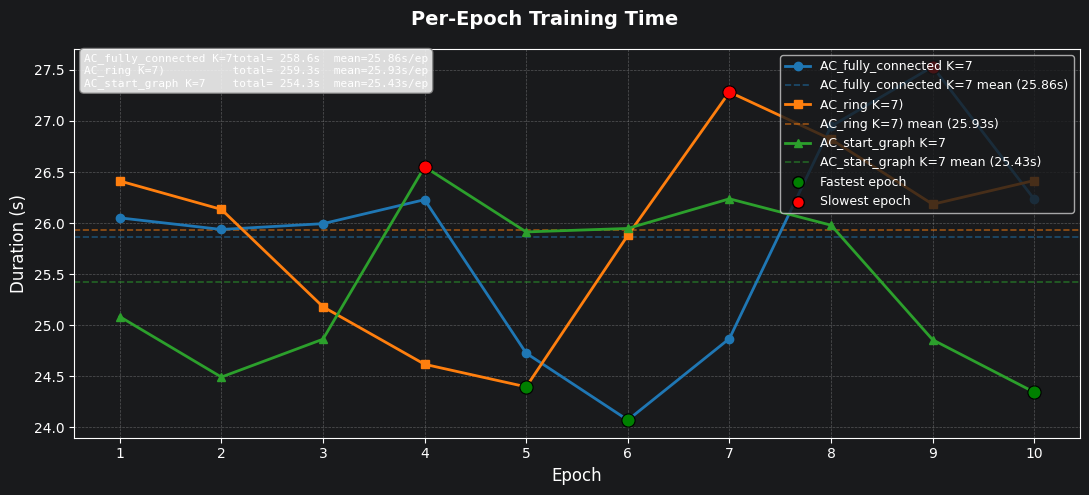


── AC_fully_connected K=7 ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_fully_connected K=7
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 331.148 MB
    Total messages    : 1,400
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 137.93 ms
    Synchro totale    : 1379.3 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


── AC_ring K=7) ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_ring K=7)
──────────────────────────────────────────────────────────
  Agents           

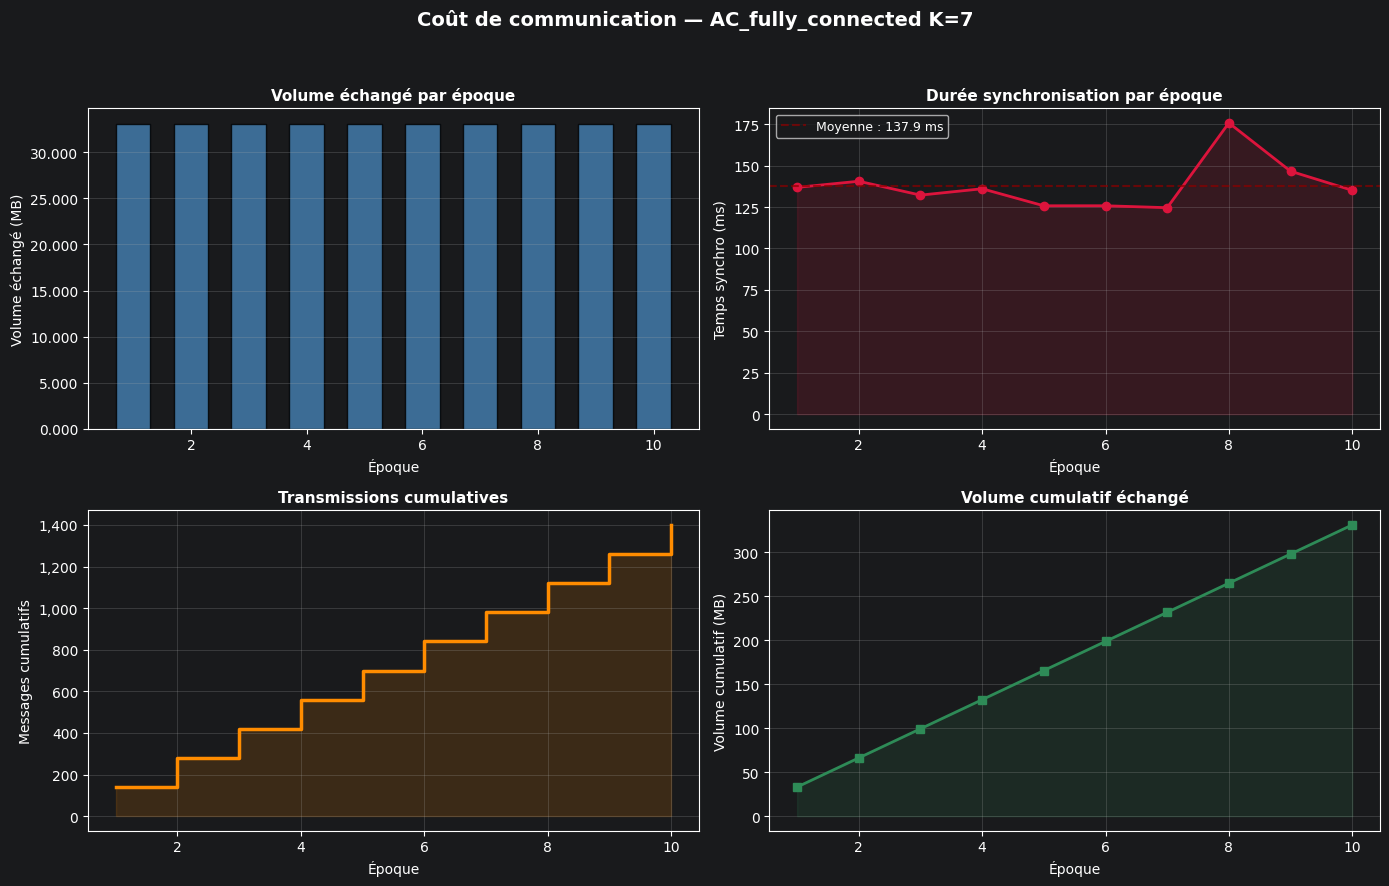


── AC_ring K=7) ──


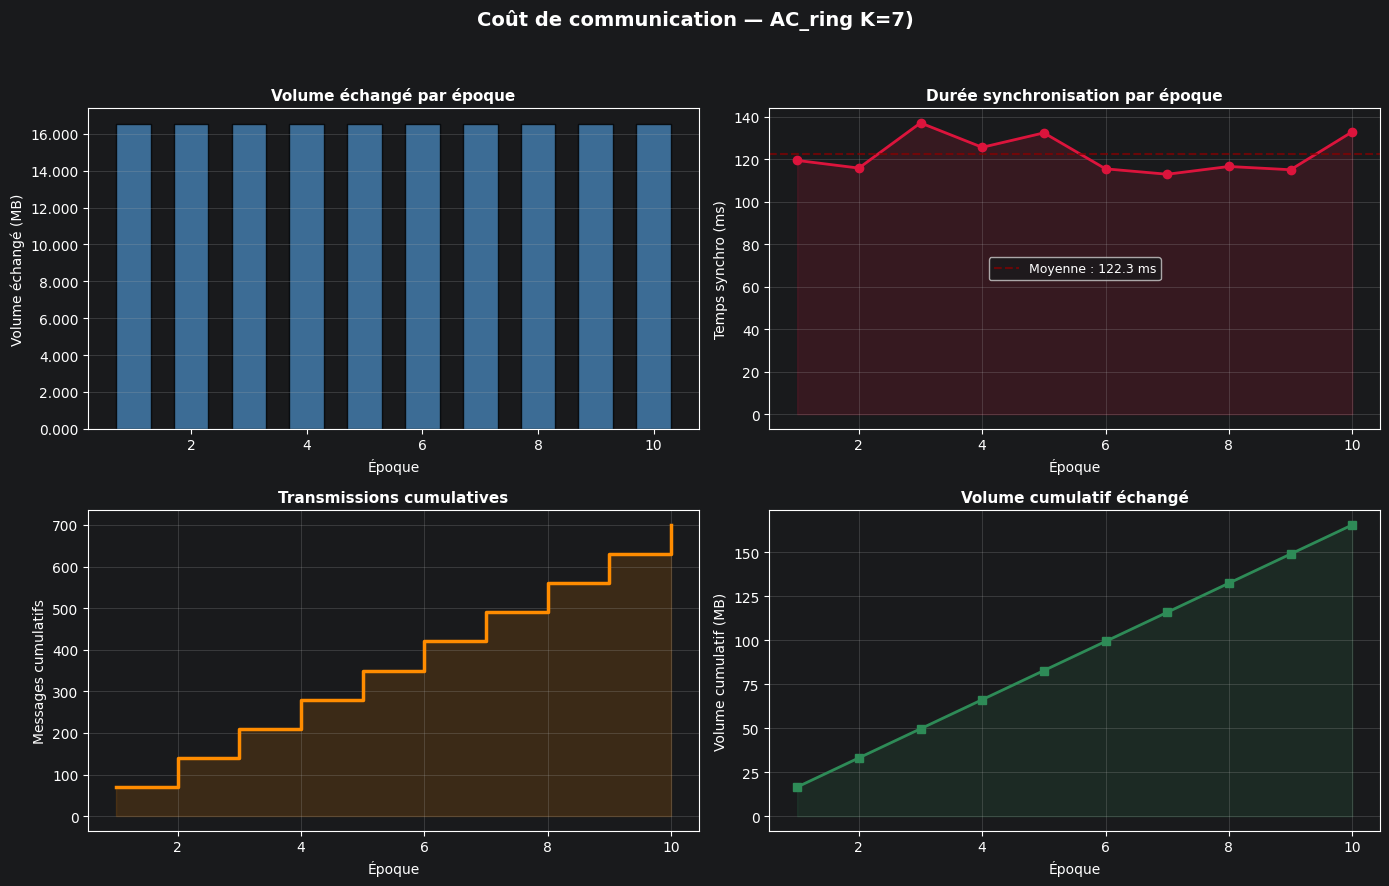


── AC_start_graph K=7 ──


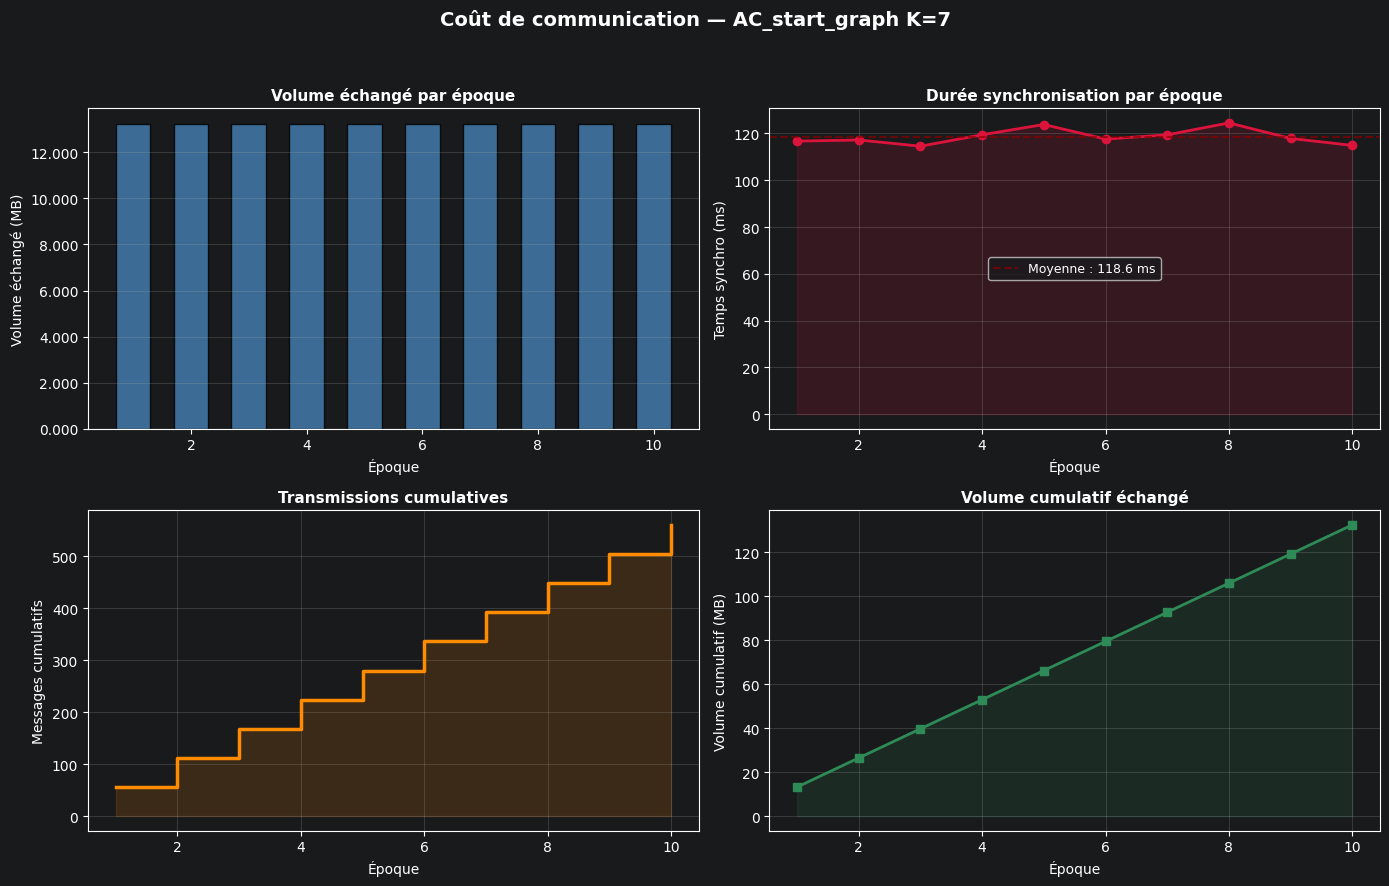


Méthode                          Val Loss    Val Acc  Train Acc
AC_fully_connected K=7             1.5951     40.87%     40.78%
AC_ring K=7)                       1.6193     39.93%     37.84%
AC_start_graph K=7                 1.6416     39.73%     38.87%


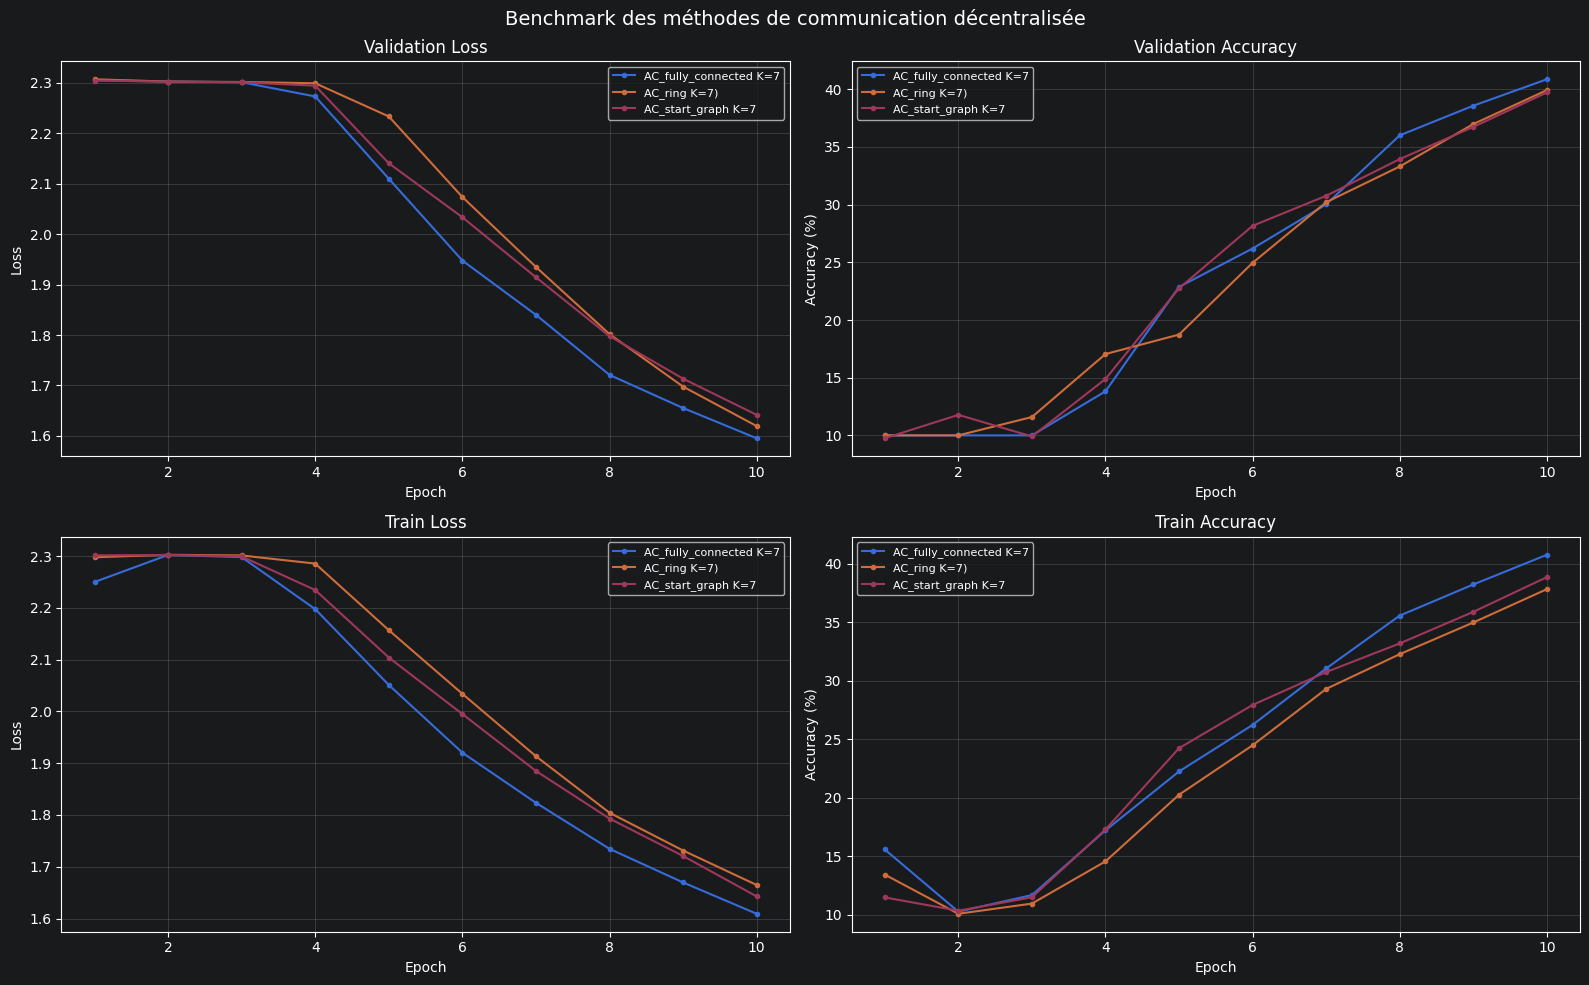

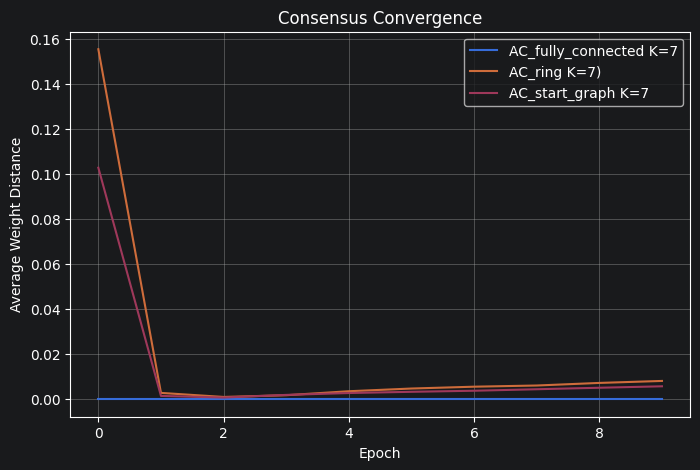

In [6]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 10

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 5
k = 7
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)



def AC_fully_connected_graph_wrapper(agent_list, graph, k, epoch, num_epochs,
                                      comm_cost=None):
    fc_graph = NetworkTopology.fully_connected_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, fc_graph, K=k,
                                  comm_cost=comm_cost)


def AC_ring_graph_wrapper(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.cycle_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, graph, K=k, comm_cost=comm_cost)


def AC_start_graph_wrapper(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    star_graph = NetworkTopology.star_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, star_graph, K=k,
                                  comm_cost=comm_cost)

# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {
    f"AC_fully_connected K={k}"  : AC_fully_connected_graph_wrapper,
    f"AC_ring K={k})"            : AC_ring_graph_wrapper,
    f"AC_start_graph K={k}"      : AC_start_graph_wrapper,
}

results,comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=none,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

# ── Résultats ──────────────────────────────────────────────
comparator.rank()
print_benchmark_summary(results)
plot_all_benchmark_metrics(results)

plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.summary()

for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.plot()


print_benchmark_summary(results)
plot_all_benchmark_metrics(results)
plot_average_distance(results)

0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775

  RUN — méthode : AC_fully_connected K=10
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555], Sum: 27775
  [Epoch 1/10] threads started …
Agent 1 start
Agent 2 start
Agent 0 start
Agent 4 start
Agent 3 start
Model1 - Acc:13.05 % - Loss:2.293761496782303 %
Model2 - Acc:17.24 % - Loss:2.24710403072834 %
Model0 - Acc:13.12 % - Loss:2.2761942644119264 %
Model4 - Acc:13.55 % - Loss:2.2888785145282746 %
Model3 - Acc:13.33 % - Loss:2.2925807356834413 %
[DEBUG] set_epoch_messages called → 200 messages
    → avrg distance after iteration 1: 0.000000
    → avrg distance after iteration 2: 0.000000
    → avrg distance after iteration 3: 0.000000
    → avrg distance after iteration 4: 0.000000
    → avrg distance after iteration 5: 0.000000
    → avrg distance after iteration 6: 0.000000
    → avrg distance after iteration 7: 0.000000
    → avrg distance after iteration 8: 0.000000
    → avrg distance after iteration

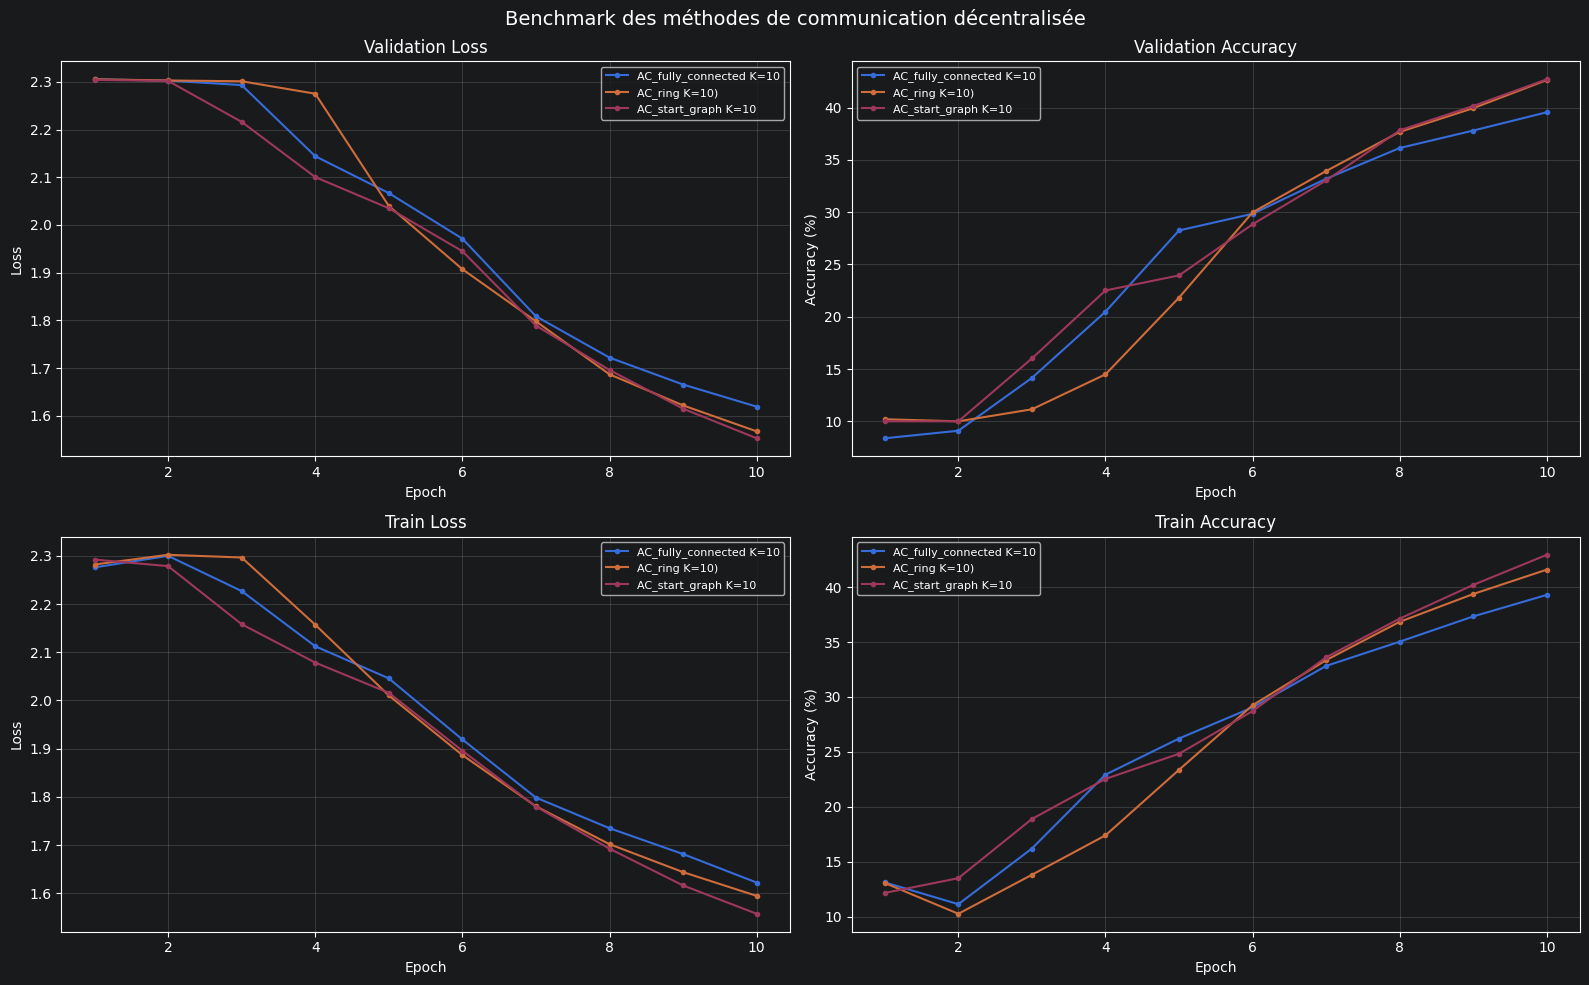

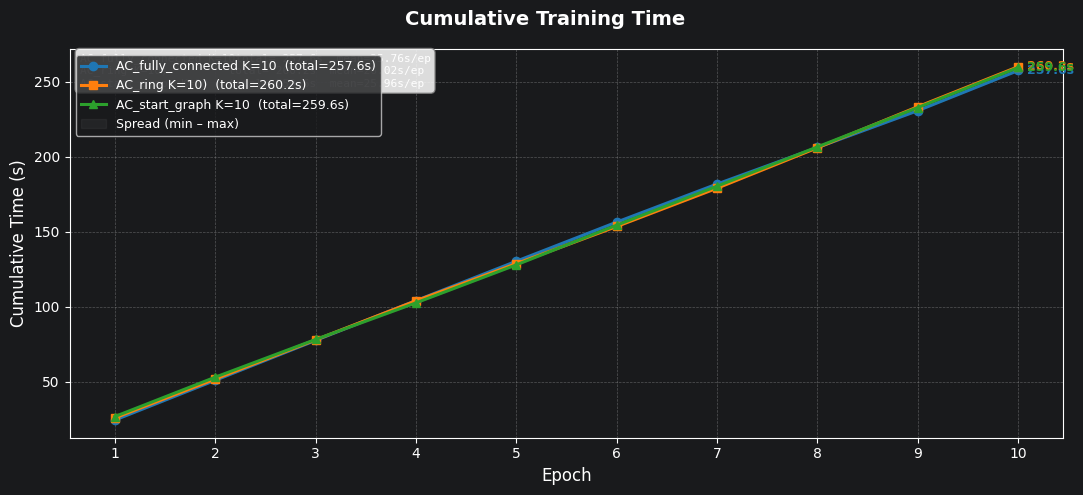

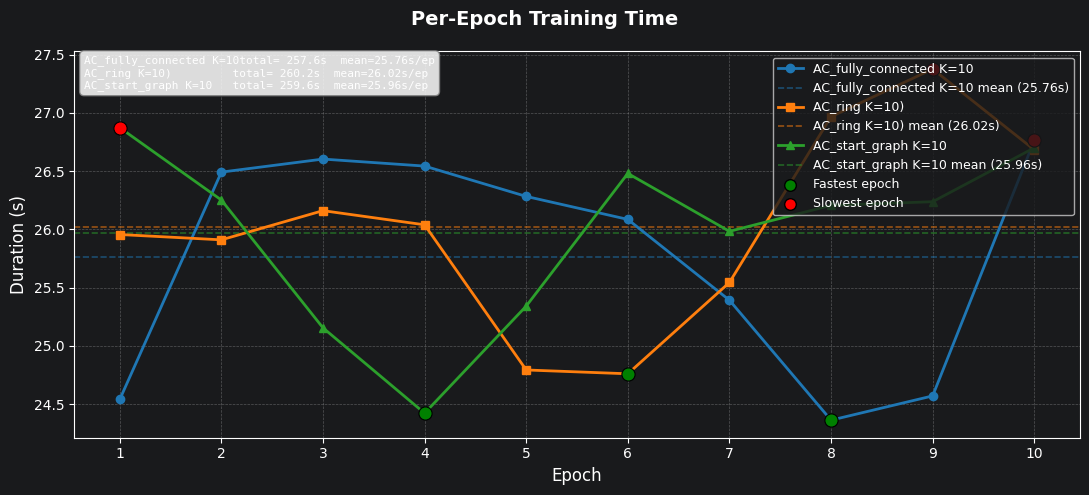


── AC_fully_connected K=10 ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_fully_connected K=10
──────────────────────────────────────────────────────────
  Agents              : 5
  Paramètres/modèle   : 62,006
  Époques mesurées    : 10
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 473.068 MB
    Total messages    : 2,000
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 189.23 ms
    Synchro totale    : 1892.3 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


── AC_ring K=10) ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_ring K=10)
──────────────────────────────────────────────────────────
  Agents       

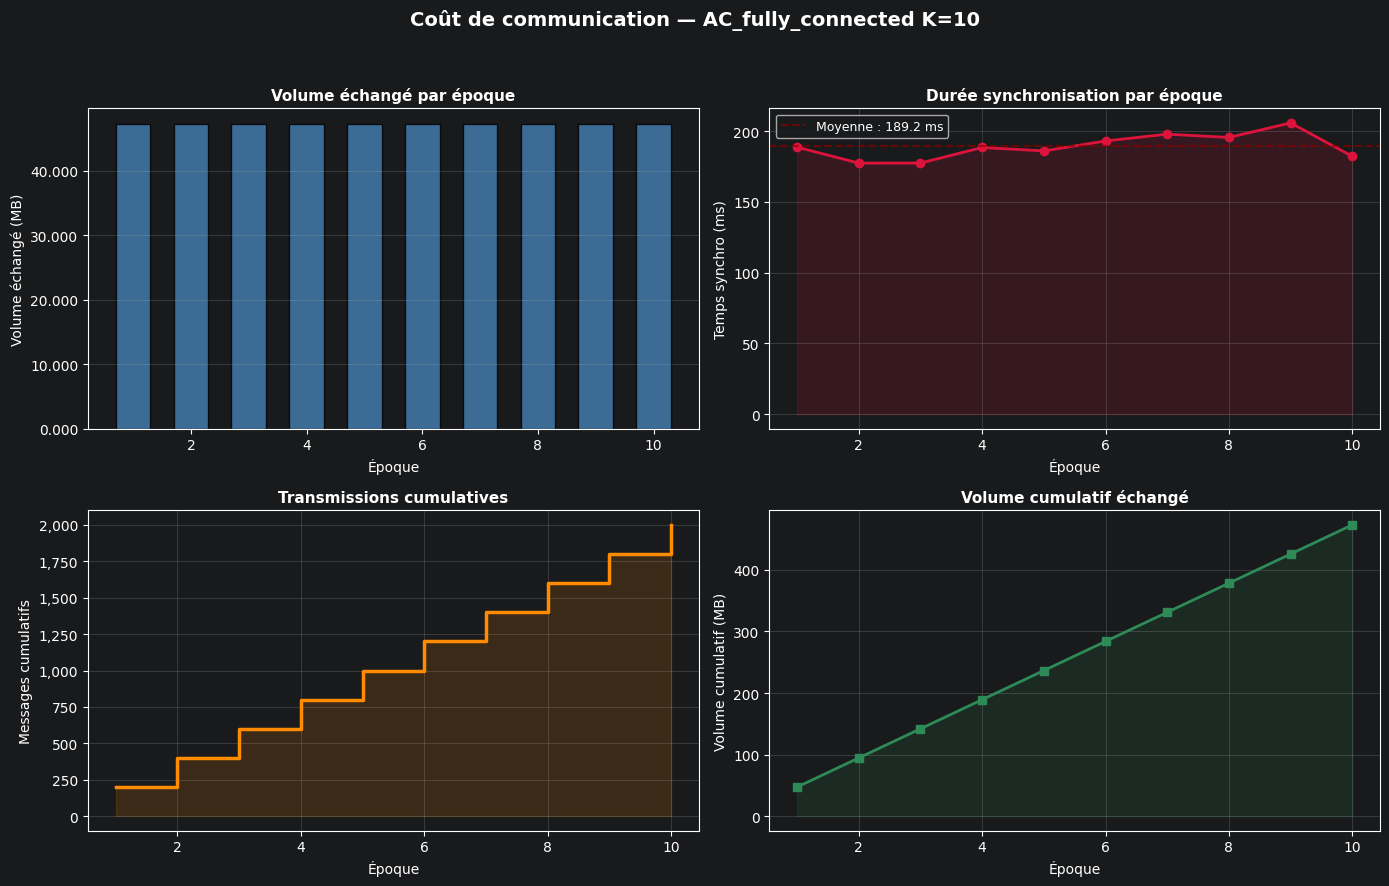


── AC_ring K=10) ──


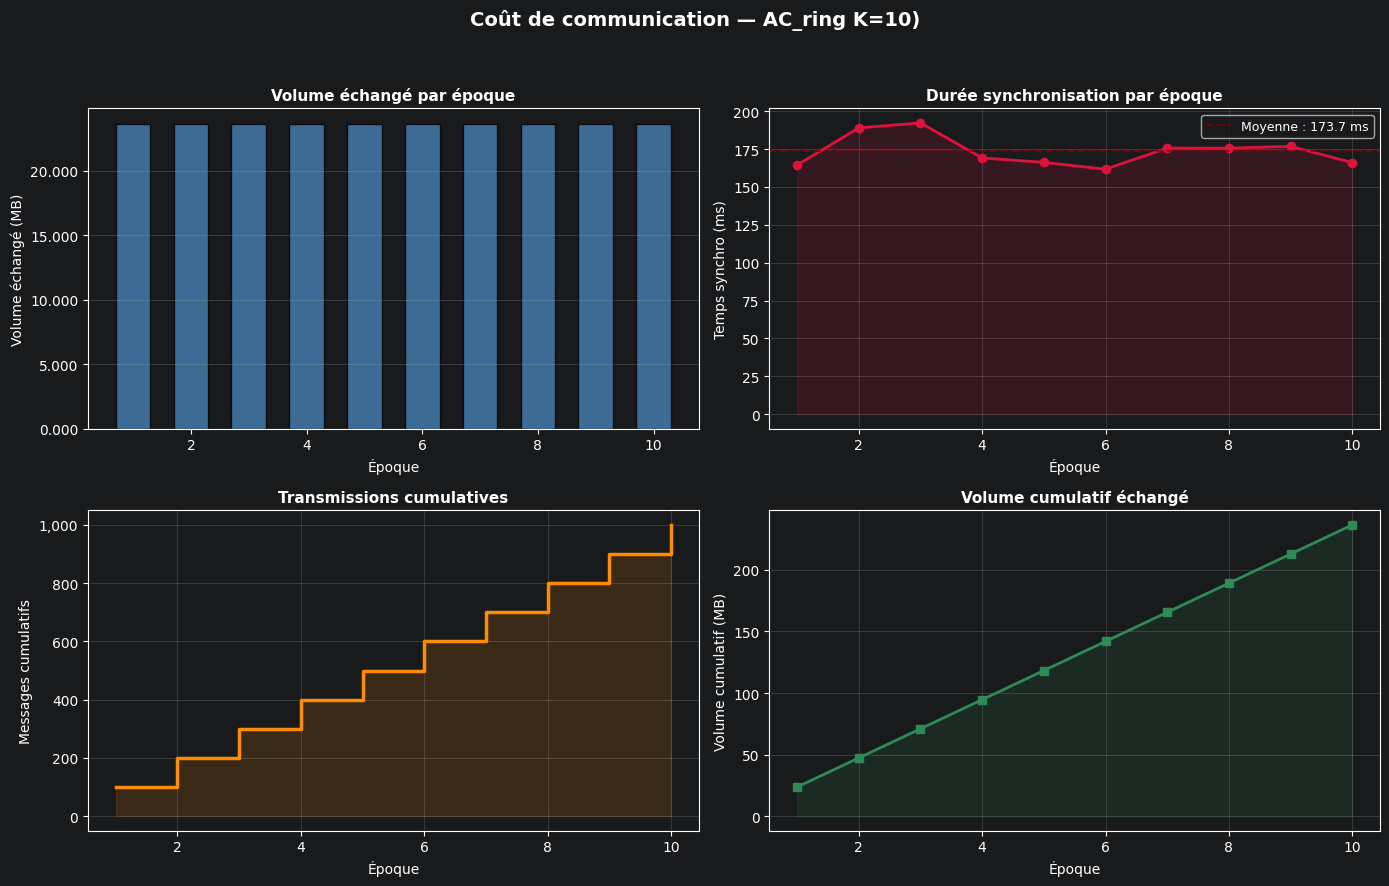


── AC_start_graph K=10 ──


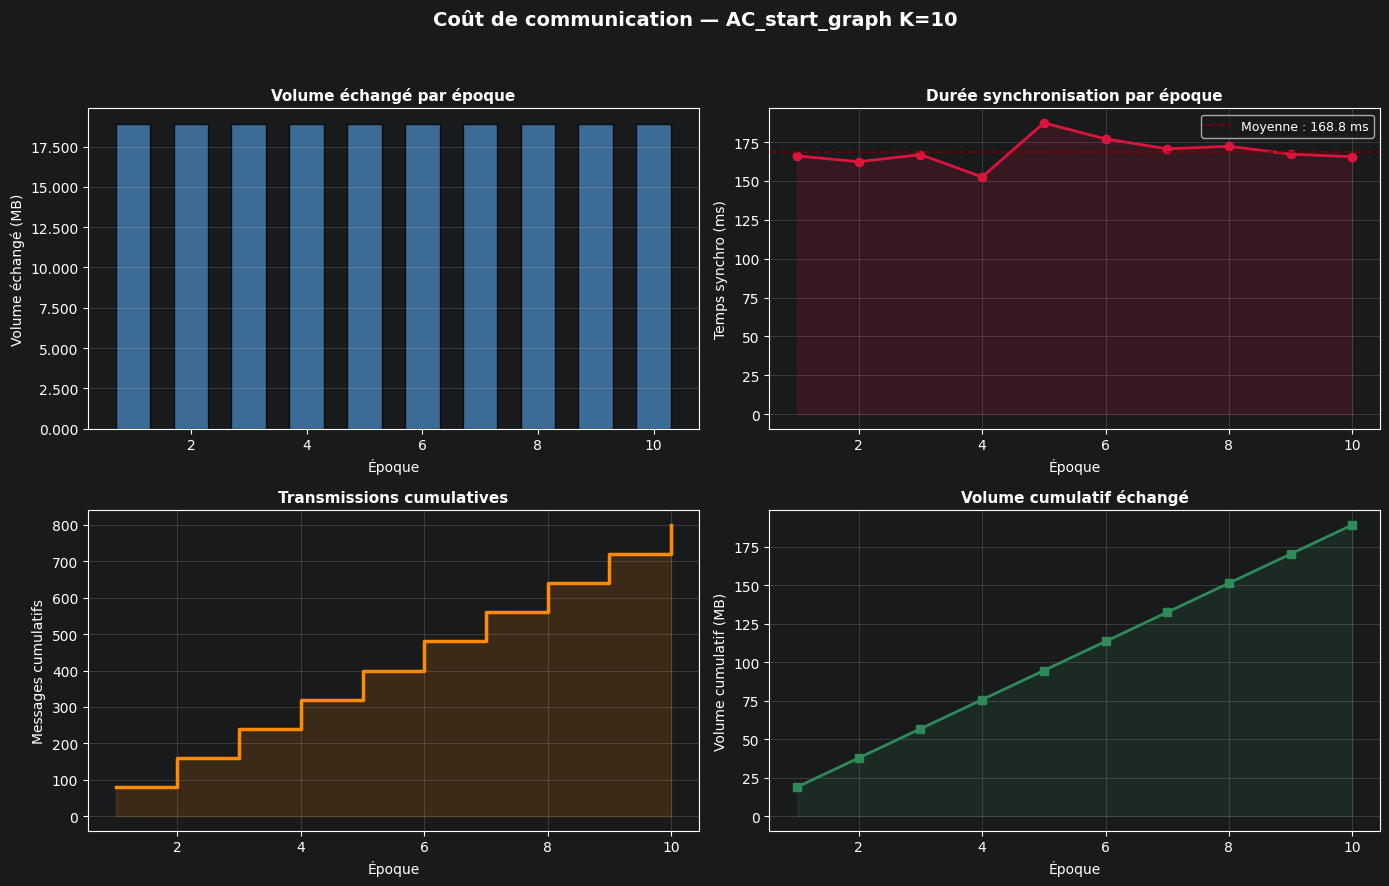


Méthode                          Val Loss    Val Acc  Train Acc
AC_fully_connected K=10            1.6194     39.55%     39.30%
AC_ring K=10)                      1.5677     42.63%     41.60%
AC_start_graph K=10                1.5532     42.70%     42.95%


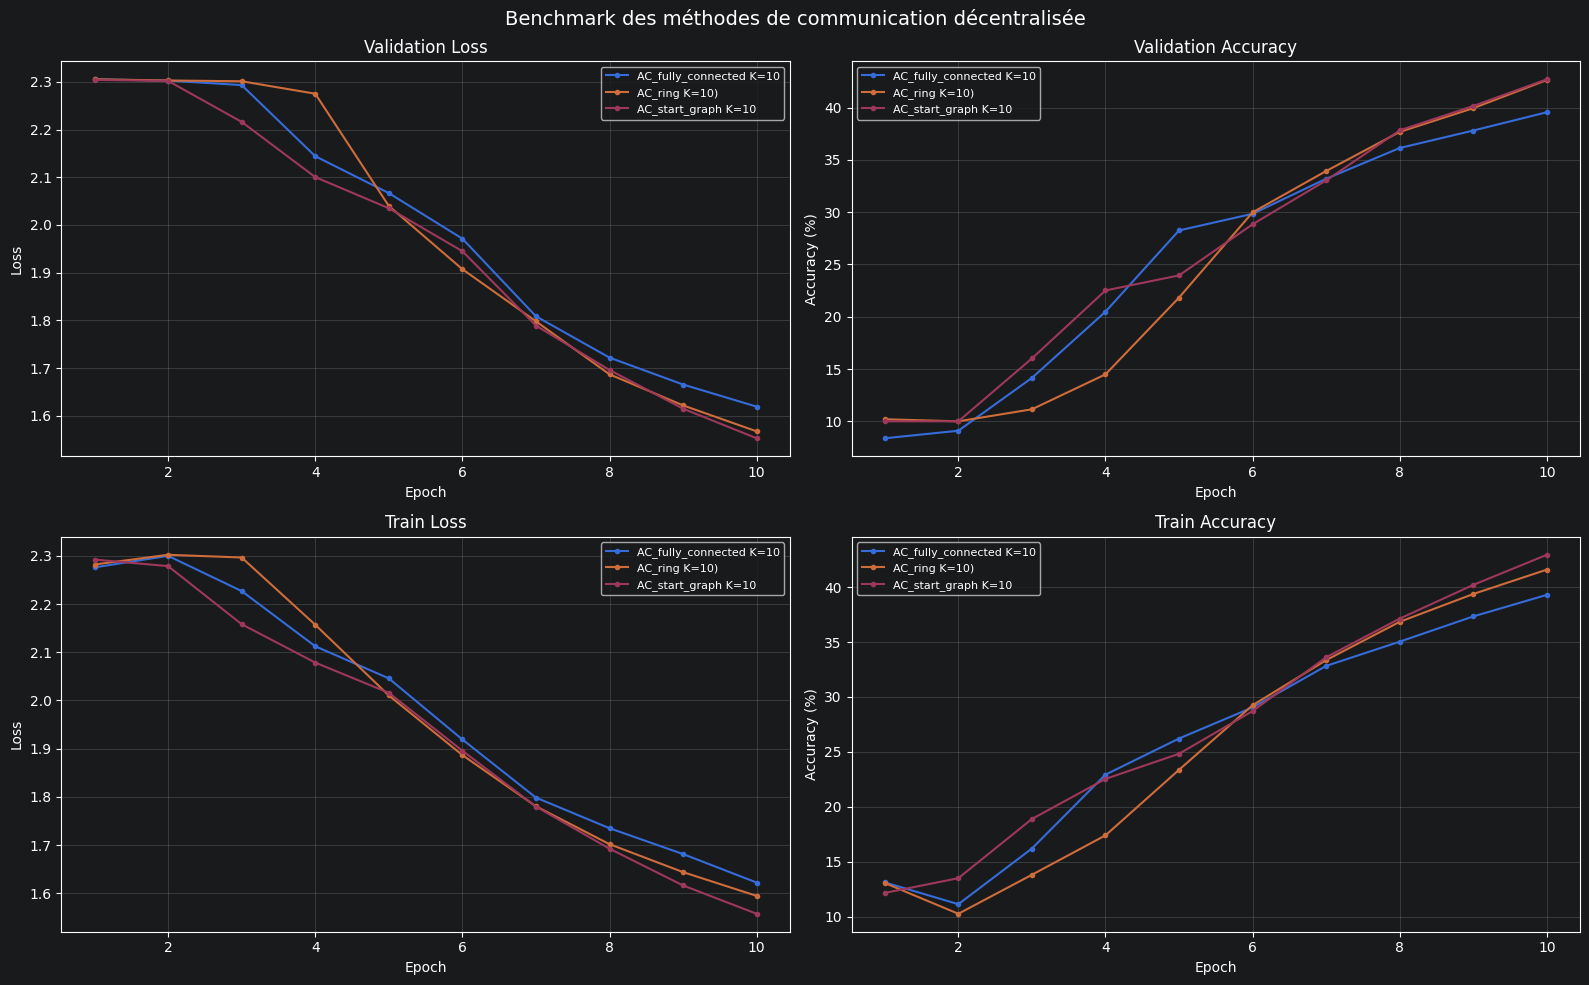

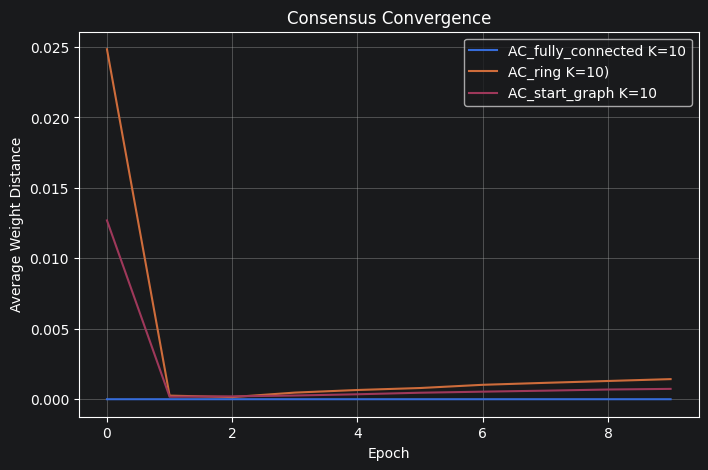

In [7]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 10

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 5
k = 10
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)



def AC_fully_connected_graph_wrapper(agent_list, graph, k, epoch, num_epochs,
                                      comm_cost=None):
    fc_graph = NetworkTopology.fully_connected_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, fc_graph, K=k,
                                  comm_cost=comm_cost)


def AC_ring_graph_wrapper(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.cycle_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, graph, K=k, comm_cost=comm_cost)


def AC_start_graph_wrapper(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    star_graph = NetworkTopology.star_graph(len(agent_list))
    Average_consensus_algorithm_K(agent_list, star_graph, K=k,
                                  comm_cost=comm_cost)

# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {
    f"AC_fully_connected K={k}"  : AC_fully_connected_graph_wrapper,
    f"AC_ring K={k})"            : AC_ring_graph_wrapper,
    f"AC_start_graph K={k}"      : AC_start_graph_wrapper,
}

results,comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=none,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

# ── Résultats ──────────────────────────────────────────────
comparator.rank()
print_benchmark_summary(results)
plot_all_benchmark_metrics(results)

plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.summary()

for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.plot()


print_benchmark_summary(results)
plot_all_benchmark_metrics(results)
plot_average_distance(results)